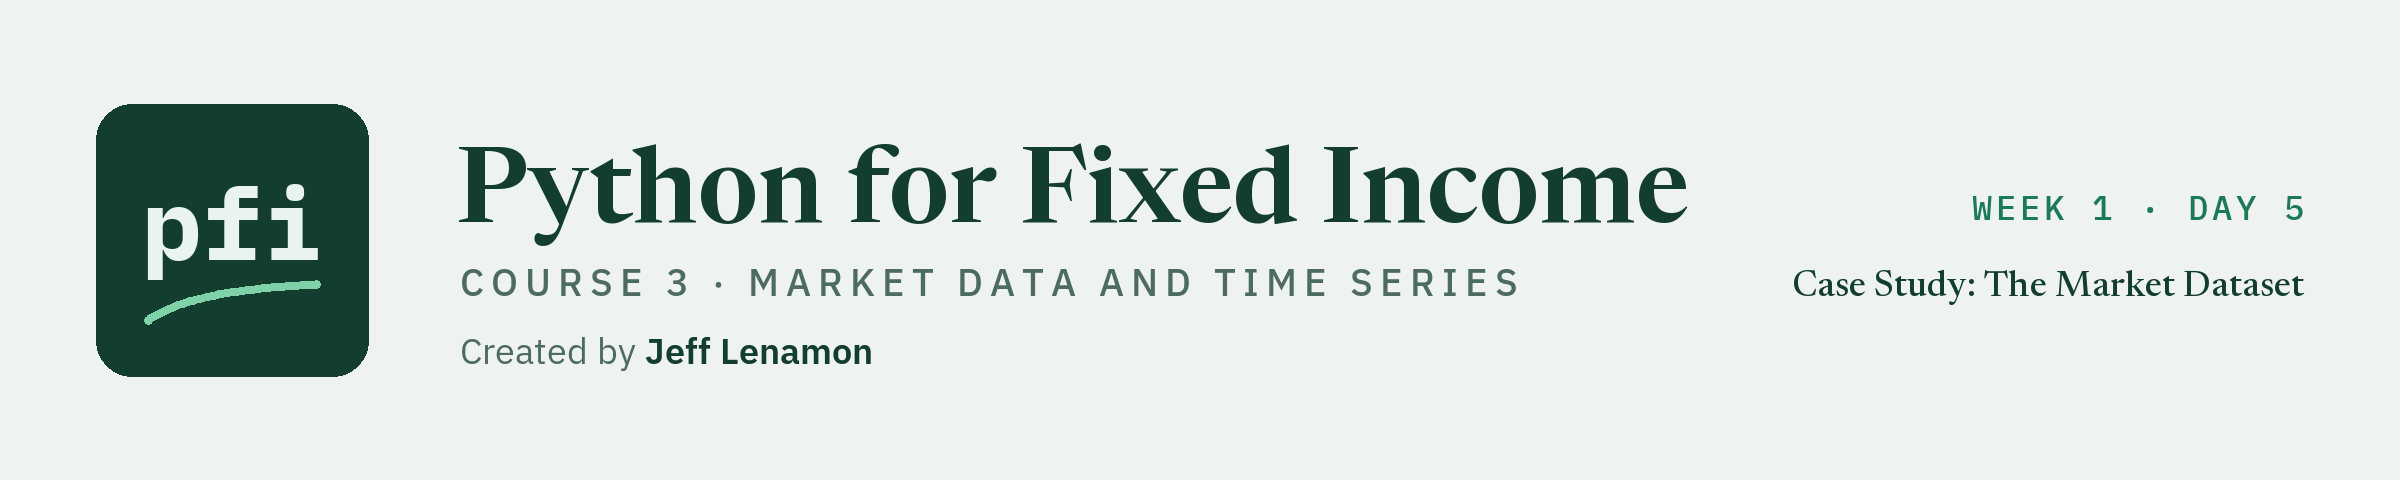

# Case Study: The Market Dataset

Week 1, Day 5. The last day of week 1. First, a cache, so a series is downloaded once a day and a licensed series is never stored. Then the case study: the course's daily market dataset, built and checked with everything week 1 taught.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course3_market_data/week1/day5/05_case_study_the_market_dataset.ipynb)

Four days of week 1 gave you a key that never leaks, FRED's JSON turned into a dated series, the market's own calendar, and the as-of value. Today puts them to work. It has two halves.

**The hands-on half** adds the last three functions of week 1 to `marketdata.py`. A notebook that pulls eleven Treasury series sends eleven requests every time it runs. A **cache** keeps a copy of each series on disk, so the second run of the day sends none. The cache has one firm rule: data whose provider forbids storing it, ICE BofA's and Moody's series on FRED, is never written to it.

**The case study** builds the dataset every notebook of weeks 2 and 3 starts from: five tenors of the Treasury curve and two credit spreads, one row per market day, checked with every test week 1 taught. The spreads are **synthetic**: invented for this course, not ICE, Moody's, or any index.

Today you will:

1. See why a cache helps: FRED's rate limit, speed, and working offline.
2. Write `write_cache` and `read_cache`, and prove a round trip gives back every number exactly.
3. Write `cached_fred_series`, and see it refuse a licensed series before anything is downloaded.
4. Read what ICE's and Moody's notes on FRED say, and why their values never appear in this course.
5. Build the market dataset and check it: dates, weekends, the 126 missing weekdays, the three tenors that start late, spreads on every date, and stale values.
6. Close week 1 in Git with a tag.

**No key? Run everything anyway.** The live cells print the skip message, and the saved outputs are exactly that run.

Q. Set up today's work folder and copy today's three data files into it.

In [1]:
# today's setup: modules, the course data, a fresh work folder, and the constants the live cells use
import importlib
import os
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

import pandas as pd

# three packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("pytest", "pytest"), ("requests", "requests"), ("dotenv", "python-dotenv")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None
import pytest
import requests

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "treasury_par_yields.csv").exists()
data_folder = RAW_DATA if on_github else str(local_data) + os.sep

# 2. your own key file: in your my_bondmath folder, outside every repository. Its path is never printed.
ENV_FILE = Path.home() / "projects" / "my_bondmath" / ".env"

# 3. the two constants of the live cells
NO_KEY_MESSAGE = "Live cell skipped: no FRED key was found. Every other cell runs without one."
# ICE BofA and Moody's values stay off the screen unless you set this to True, on your own machine only
SHOW_LICENSED_VALUES = False

# 4. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course3_05_"))
os.chdir(work)

# 5. copy today's data files into the work folder
DATA_FILES = ["treasury_par_yields.csv", "course3_synthetic_spreads.csv", "course3_fred_format_dgs10.json"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES) or 'none'}")
print(f"pytest {pytest.__version__}, requests {requests.__version__}")

Work folder: pfi_course3_05_dl6ckkll, in your temp folder
Data files from the data folder of the course repo: treasury_par_yields.csv, course3_synthetic_spreads.csv, course3_fred_format_dgs10.json
pytest 9.1.1, requests 2.34.2


Q. Write `bondmath.py`, the reference copy of the module you finished in Course 2.

It is written into the work folder so that every notebook runs, in Colab too, whether or not you took Course 2. To use your own copy instead, run this line in a new cell after the next one:

```python
shutil.copy(Path.home() / "projects" / "my_bondmath" / "bondmath.py", work)
```

The saved outputs of this notebook always come from the reference copy.

In [2]:
%%writefile bondmath.py
"""bondmath: bond math for fixed-rate bullet bonds, checked against Excel.

Written day by day in Python for Fixed Income, Course 2: Bond Math.

Units, the same in every function:
- coupon_pct and yield_pct are annual rates in percent: 7.0 means 7 percent. Excel takes decimals (0.07).
- Prices and accrued interest are per 100 of face.
- Durations are in years, convexity in years squared, spreads in basis points.
- frequency is the number of coupons (or compounding periods) a year: 1, 2, or 4.
- basis is the day count: "30/360" (Excel basis 0) or "ACT/ACT" (Excel basis 1).
- Dates are datetime.date values.
"""
import calendar  # month lengths, used from week 2
from datetime import date  # calendar dates, used from week 2


def future_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Grow an amount at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount x (1 + rate / frequency) ** (frequency x years).
    Excel: =FV(rate_pct/100/frequency, frequency*years, 0, -amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # grow the amount over every period
    return amount * (1 + period_rate) ** periods


def present_value(amount: float, rate_pct: float, years: float, frequency: int = 2) -> float:
    """Discount an amount due in `years` at an annual rate compounded `frequency` times a year.

    Units: amount in dollars (or per 100 of face), rate_pct in percent, years in years.
    Convention: periodic compounding, amount / (1 + rate / frequency) ** (frequency x years).
    Returns a positive number for a positive amount. Excel's PV returns the same number with a
    minus sign: =-PV(rate_pct/100/frequency, frequency*years, 0, amount)
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # the rate for one period, as a decimal
    period_rate = rate_pct / 100 / frequency
    # the number of compounding periods
    periods = frequency * years
    # discount the amount over every period
    return amount / (1 + period_rate) ** periods


def cash_flows(coupon_pct: float, years: float, frequency: int = 2) -> list[tuple[float, float]]:
    """The cash flows of a bullet bond bought on a coupon date.

    Units: coupon_pct in percent of face a year, years in years. Each cash flow is per 100 of face.
    Convention: one coupon of coupon_pct / frequency every 1 / frequency years, and 100 back with
    the last coupon. Returns a list of (time in years, cash flow) pairs, earliest first.
    Raises ValueError unless years x frequency is a whole number of periods.
    """
    # stop on a frequency the course does not use
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # count the coupon periods and check they are whole
    periods = years * frequency
    if periods <= 0 or abs(periods - round(periods)) > 1e-9:
        raise ValueError(f"{years} years is not a whole number of periods at frequency {frequency}")
    periods = round(periods)
    # each coupon is the annual coupon split into equal parts
    coupon = coupon_pct / frequency
    flows = []
    for k in range(1, periods + 1):
        # the time of payment k, in years
        time_years = k / frequency
        # the last payment also returns the face of 100
        amount = coupon + 100 if k == periods else coupon
        flows.append((time_years, amount))
    return flows


def price_from_yield(coupon_pct: float, yield_pct: float, years: float, frequency: int = 2) -> float:
    """Price of a bullet bond on a coupon date, from its yield.

    Units: coupon_pct and yield_pct in percent a year, years in years, price per 100 of face.
    Convention: each cash flow is discounted at yield_pct compounded `frequency` times a year.
    On a coupon date there is no accrued interest, so this is both the clean and the dirty price.
    Excel: =-PV(yield_pct/100/frequency, frequency*years, coupon_pct/frequency, 100)
    """
    # the yield for one period, as a decimal
    period_yield = yield_pct / 100 / frequency
    price = 0.0
    for time_years, amount in cash_flows(coupon_pct, years, frequency):
        # discount each cash flow by one factor per period until it is paid
        price += amount / (1 + period_yield) ** (time_years * frequency)
    return price


def convert_yield(yield_pct: float, from_frequency: int, to_frequency: int) -> float:
    """The same yield restated at another compounding frequency.

    Units: yield_pct in percent a year; the result is in percent a year.
    Convention: both rates grow 100 to the same amount in one year.
    Excel: convert_yield(y, f, 1) is =EFFECT(y/100, f)*100, and convert_yield(y, 1, f) is =NOMINAL(y/100, f)*100.
    """
    # stop on a frequency the course does not use
    for frequency in (from_frequency, to_frequency):
        if frequency not in (1, 2, 4):
            raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    # how much 1 grows to in one year at the original frequency
    growth_one_year = (1 + yield_pct / 100 / from_frequency) ** from_frequency
    # the rate per period at the new frequency that gives the same growth
    period_rate = growth_one_year ** (1 / to_frequency) - 1
    # back to an annual rate in percent
    return period_rate * to_frequency * 100


def yield_from_price(coupon_pct: float, price: float, years: float, frequency: int = 2) -> float:
    """Yield of a bullet bond on a coupon date, from its price, by bisection.

    Units: coupon_pct in percent a year, price per 100 of face, years in years; the result is in percent.
    Convention: the yield, compounded `frequency` times a year, at which price_from_yield equals price.
    The search runs between -5 and 100 percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Excel: =RATE(frequency*years, coupon_pct/frequency, -price, 100)*frequency, then x 100.
    """
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price_from_yield(coupon_pct, low_pct, years, frequency)
    lowest_price = price_from_yield(coupon_pct, high_pct, years, frequency)
    if not lowest_price <= price <= highest_price:
        raise ValueError(f"price {price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price_from_yield(coupon_pct, mid_pct, years, frequency) > price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def add_months(d: date, months: int) -> date:
    """Move a date by whole months, keeping the day of the month where the month allows it.

    Units: d is a date, months a whole number (negative moves back).
    Convention: the day is clamped to the length of the new month, so 31 August minus 6 months is
    28 February (29 February in a leap year). Excel: =EDATE(d, months)
    """
    # count months from year 0 so the year and month come out of one division
    month_index = d.year * 12 + (d.month - 1) + months
    year, month_zero_based = divmod(month_index, 12)
    month = month_zero_based + 1
    # the number of days in the new month
    days_in_month = calendar.monthrange(year, month)[1]
    # keep the day, or use the last day of a shorter month
    return date(year, month, min(d.day, days_in_month))


def coupon_dates(settlement: date, maturity: date, frequency: int = 2) -> list[date]:
    """The previous coupon date, then every coupon date left through maturity.

    Units: dates. Convention: coupon dates are counted back from maturity in steps of 12 / frequency
    months, each one computed from maturity directly, so a 31st never drifts to the 28th. If maturity
    is the last day of its month, every coupon date is the last day of its month (Excel's rule).
    The previous coupon date is the last one on or before settlement.
    So [0] is Excel's COUPPCD, [1] is COUPNCD, and len - 1 is COUPNUM.
    """
    # stop on bad input
    if frequency not in (1, 2, 4):
        raise ValueError(f"frequency must be 1, 2, or 4, not {frequency}")
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # months between coupons
    step_months = 12 // frequency
    # does the bond mature on the last day of a month?
    month_end = maturity.day == calendar.monthrange(maturity.year, maturity.month)[1]
    dates = []
    k = 0
    while True:
        # coupon k steps back from maturity, computed from maturity itself
        coupon_date = add_months(maturity, -k * step_months)
        if month_end:
            # the month-end rule: move to the last day of that month
            last_day = calendar.monthrange(coupon_date.year, coupon_date.month)[1]
            coupon_date = date(coupon_date.year, coupon_date.month, last_day)
        dates.append(coupon_date)
        # stop once we reach the previous coupon date
        if coupon_date <= settlement:
            break
        k += 1
    # earliest first
    dates.reverse()
    return dates


def days_30_360(start: date, end: date) -> int:
    """Days from start to end on the US 30/360 basis, as Excel's COUPDAYBS and YEARFRAC(..., 0) count them.

    Units: dates in, whole days out. Every month counts as 30 days and every year as 360.
    Convention, with D1 the start day and D2 the end day:
    1. If start is the last day of February, D1 = 30.
    2. If start and end are both the last day of February, D2 = 30.
    3. If D1 is 31, D1 = 30.
    4. If D2 is 31 and the start day was 30 or 31, D2 = 30. (Excel looks at the start date's own
       day here, so a start on 28 February and an end on the 31st keeps D2 = 31.)
    Days = 360 x (Y2 - Y1) + 30 x (M2 - M1) + (D2 - D1).
    Excel's DAYS360 uses different February rules and is not the same count.
    """
    d1, d2 = start.day, end.day
    start_is_feb_end = start.month == 2 and start.day == calendar.monthrange(start.year, 2)[1]
    end_is_feb_end = end.month == 2 and end.day == calendar.monthrange(end.year, 2)[1]
    # rule 1: the last day of February counts as the 30th
    if start_is_feb_end:
        d1 = 30
    # rule 2: both dates on the last day of February
    if start_is_feb_end and end_is_feb_end:
        d2 = 30
    # rule 3: a 31st start counts as the 30th
    if start.day == 31:
        d1 = 30
    # rule 4: a 31st end counts as the 30th when the start day was 30 or 31
    if end.day == 31 and start.day >= 30:
        d2 = 30
    return 360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)


def coupon_period_days(settlement: date, maturity: date, frequency: int = 2,
                       basis: str = "30/360") -> tuple[int, int, int]:
    """Day counts of the coupon period that holds settlement: (A, E, DSC).

    Units: whole days.
    A is days from the previous coupon to settlement (Excel COUPDAYBS).
    E is days in the coupon period: 360 / frequency under 30/360 (Excel COUPDAYS), and the actual days
    from the previous to the next coupon under ACT/ACT.
    DSC is days from settlement to the next coupon, as Excel's PRICE uses it: E - A under 30/360
    (this can differ from COUPDAYSNC near the end of February), actual days under ACT/ACT.
    """
    # stop on a basis the course does not use (coupon_dates checks frequency and dates)
    if basis not in ("30/360", "ACT/ACT"):
        raise ValueError(f'basis must be "30/360" or "ACT/ACT", not {basis!r}')
    # the previous and next coupon dates
    dates = coupon_dates(settlement, maturity, frequency)
    previous_coupon, next_coupon = dates[0], dates[1]
    if basis == "30/360":
        # 30/360: A by the 30/360 rules, a fixed period length, and DSC as what is left of it
        days_accrued = days_30_360(previous_coupon, settlement)
        days_in_period = 360 // frequency
        days_to_next = days_in_period - days_accrued
    else:
        # ACT/ACT: every count is actual calendar days
        days_accrued = (settlement - previous_coupon).days
        days_in_period = (next_coupon - previous_coupon).days
        days_to_next = (next_coupon - settlement).days
    return days_accrued, days_in_period, days_to_next


def accrued_interest(settlement: date, maturity: date, coupon_pct: float, frequency: int = 2,
                     basis: str = "30/360") -> float:
    """Accrued interest the buyer pays the seller, per 100 of face.

    Units: coupon_pct in percent a year; the result is per 100 of face.
    Convention: coupon_pct / frequency x A / E, with A and E from coupon_period_days.
    Excel (30/360): =100*coupon_pct/100/frequency*COUPDAYBS(...)/COUPDAYS(...)
    """
    # A and E for this settlement
    days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
    # one coupon, times the share of the period that has passed
    return coupon_pct / frequency * days_accrued / days_in_period


def price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
          basis: str = "30/360") -> float:
    """Clean price per 100 of face on any settlement date, as Excel's PRICE.

    Units: coupon_pct and yield_pct in percent a year; the result is a clean price per 100 of face.
    Convention: yield compounded `frequency` times a year. w = DSC / E is the part of a period left
    until the next coupon. Dirty price = sum over the N coupons left of CF_k / (1 + y/f) ** (w + k).
    In the final coupon period (N = 1) Excel uses simple interest: dirty = (100 + CF) / (1 + w x y/f).
    Clean = dirty - accrued interest.
    Excel: =PRICE(settlement, maturity, coupon_pct/100, yield_pct/100, 100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    days_accrued, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    # coupons left, the fraction of a period to the next one, the period yield, and one coupon
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    if coupons_left == 1:
        # final period: simple interest on the last coupon and the face
        dirty = (100 + coupon) / (1 + w * period_yield)
    else:
        dirty = 0.0
        for k in range(coupons_left):
            # the last cash flow also returns the face
            cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
            dirty += cash_flow / (1 + period_yield) ** (w + k)
    # the quote is clean: take off the accrued interest
    return dirty - accrued_interest(settlement, maturity, coupon_pct, frequency, basis)


def dirty_price(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                basis: str = "30/360") -> float:
    """Dirty (full, invoice) price per 100 of face: the clean price plus accrued interest.

    Units and convention as price(). Excel: =PRICE(...) + the accrued formula.
    """
    # clean price plus accrued interest
    return (price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
            + accrued_interest(settlement, maturity, coupon_pct, frequency, basis))


def yield_to_maturity(settlement: date, maturity: date, coupon_pct: float, clean_price: float,
                      frequency: int = 2, basis: str = "30/360") -> float:
    """Yield in percent from a clean price on any settlement date, by bisection, as Excel's YIELD x 100.

    Units: coupon_pct in percent a year, clean_price per 100 of face; the result is in percent a year.
    Convention: the yield at which price() equals clean_price. The search runs between -5 and 100
    percent and stops when the bracket is narrower than 1e-10 percent.
    Raises ValueError if the price is outside the prices at those two yields.
    Final coupon period: Excel's YIELD uses a formula instead of a search, with DSR, the days from
    settlement to maturity, counted by days_30_360 under 30/360 (actual days under ACT/ACT):
    yield = ((100 + CF) - dirty) / dirty x frequency x E / DSR. Under 30/360 DSR can differ from the
    E - A that PRICE uses, so in those cases YIELD does not return the yield PRICE was given.
    Excel: =YIELD(settlement, maturity, coupon_pct/100, clean_price, 100, frequency, basis)*100
    """
    # final coupon period: Excel's formula (coupon_dates and coupon_period_days check the inputs)
    if len(coupon_dates(settlement, maturity, frequency)) - 1 == 1:
        days_accrued, days_in_period, _ = coupon_period_days(settlement, maturity, frequency, basis)
        if basis == "30/360":
            days_to_maturity = days_30_360(settlement, maturity)
        else:
            days_to_maturity = (maturity - settlement).days
        coupon = coupon_pct / frequency
        # the dirty price paid, and what comes back at maturity
        paid = clean_price + coupon * days_accrued / days_in_period
        received = 100 + coupon
        # the simple return over the days left, made annual, in percent
        return (received - paid) / paid * frequency * days_in_period / days_to_maturity * 100
    # the bracket: price falls as yield rises, so the low yield gives the high price
    low_pct, high_pct = -5.0, 100.0
    highest_price = price(settlement, maturity, coupon_pct, low_pct, frequency, basis)
    lowest_price = price(settlement, maturity, coupon_pct, high_pct, frequency, basis)
    if not lowest_price <= clean_price <= highest_price:
        raise ValueError(f"price {clean_price} is outside {lowest_price:.6f} to {highest_price:.6f}, "
                         f"the prices at yields of {high_pct} and {low_pct} percent")
    # halve the bracket until it is narrow enough
    while high_pct - low_pct > 1e-10:
        mid_pct = (low_pct + high_pct) / 2
        if price(settlement, maturity, coupon_pct, mid_pct, frequency, basis) > clean_price:
            # price too high at mid, so the yield is above mid
            low_pct = mid_pct
        else:
            # price too low (or equal) at mid, so the yield is at or below mid
            high_pct = mid_pct
    # the middle of the final bracket
    return (low_pct + high_pct) / 2


def macaulay_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Macaulay duration in years: the present-value weighted average time of the cash flows.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: t_k = (w + k) / frequency years, PV_k = CF_k / (1 + y/f) ** (w + k), and
    duration = sum of t_k x PV_k / sum of PV_k. In the final period this is DSC / E / frequency.
    Excel: =DURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, weighted_time = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow, its time in years, and its present value
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        pv = cash_flow / (1 + period_yield) ** (w + k)
        total_pv += pv
        weighted_time += time_years * pv
    # the weighted average time
    return weighted_time / total_pv


def modified_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                      basis: str = "30/360") -> float:
    """Modified duration in years: the percent price change for a 1-point (100 bp) change in yield.

    Units: coupon_pct and yield_pct in percent a year; the result is in years.
    Convention: Macaulay duration / (1 + y / frequency), with y = yield_pct / 100.
    Excel: =MDURATION(settlement, maturity, coupon_pct/100, yield_pct/100, frequency, basis)
    """
    # divide Macaulay duration by one plus the period yield
    period_yield = yield_pct / 100 / frequency
    return macaulay_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis) / (1 + period_yield)


def dv01(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
         basis: str = "30/360") -> float:
    """DV01: price points per 100 of face for a 1 basis point fall in yield, positive for a long position.

    Units: coupon_pct and yield_pct in percent a year; the result is in price points per 100 of face per bp.
    Convention: modified duration x dirty price x 0.0001. Position DV01 in dollars = dv01 x par / 100.
    Excel: =MDURATION(...)*(PRICE(...)+accrued)/10000
    """
    # modified duration times the dirty price, for one basis point (0.0001 as a decimal)
    duration_years = modified_duration(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    return duration_years * full_price * 0.0001


def convexity(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
              basis: str = "30/360") -> float:
    """Convexity in years squared, unscaled (not divided by 100 or by 2).

    Units: coupon_pct and yield_pct in percent a year; the result is in years squared.
    Convention: (1 / P) x sum of CF_k x t_k x (t_k + 1/f) / (1 + y/f) ** (f t_k + 2), where
    t_k = (w + k) / f and P is the sum of the discounted cash flows. Price change estimate:
    dP / P = -D_mod x dy + 0.5 x convexity x dy ** 2, with dy in decimal.
    Excel has no convexity function; the check is a central difference on three PRICE cells.
    """
    # the coupon dates and day counts (these check frequency, basis, and dates)
    dates = coupon_dates(settlement, maturity, frequency)
    _, days_in_period, days_to_next = coupon_period_days(settlement, maturity, frequency, basis)
    coupons_left = len(dates) - 1
    w = days_to_next / days_in_period
    period_yield = yield_pct / 100 / frequency
    coupon = coupon_pct / frequency
    total_pv, curvature = 0.0, 0.0
    for k in range(coupons_left):
        # each cash flow and its time in years
        cash_flow = coupon + 100 if k == coupons_left - 1 else coupon
        time_years = (w + k) / frequency
        # its present value, and its term in the convexity sum
        total_pv += cash_flow / (1 + period_yield) ** (w + k)
        curvature += (cash_flow * time_years * (time_years + 1 / frequency)
                      / (1 + period_yield) ** (frequency * time_years + 2))
    # divide by the price
    return curvature / total_pv


def interpolate_yield(tenor_years: float, curve_tenors: list[float], curve_yields_pct: list[float]) -> float:
    """Yield at any tenor by straight-line interpolation on a curve, flat beyond its ends.

    Units: tenors in years, yields in percent; the result is in percent.
    Convention: linear in yield against tenor between the two curve points around tenor_years. Below
    the first tenor the first yield is used, above the last tenor the last yield (as numpy.interp).
    Raises ValueError if the lists differ in length, are empty, or the tenors do not ascend.
    """
    # stop on a curve the function cannot read
    if len(curve_tenors) != len(curve_yields_pct) or len(curve_tenors) == 0:
        raise ValueError("curve_tenors and curve_yields_pct must be non-empty and the same length")
    for i in range(1, len(curve_tenors)):
        if curve_tenors[i] <= curve_tenors[i - 1]:
            raise ValueError(f"curve tenors must ascend: {curve_tenors[i - 1]} then {curve_tenors[i]}")
    # flat beyond the ends
    if tenor_years <= curve_tenors[0]:
        return curve_yields_pct[0]
    if tenor_years >= curve_tenors[-1]:
        return curve_yields_pct[-1]
    # find the two tenors around tenor_years
    i = 1
    while curve_tenors[i] < tenor_years:
        i += 1
    left_tenor, right_tenor = curve_tenors[i - 1], curve_tenors[i]
    left_yield, right_yield = curve_yields_pct[i - 1], curve_yields_pct[i]
    # move along the straight line between them
    slope = (right_yield - left_yield) / (right_tenor - left_tenor)
    return left_yield + slope * (tenor_years - left_tenor)


def years_to_maturity(settlement: date, maturity: date) -> float:
    """Years from settlement to maturity on the US 30/360 basis.

    Units: dates in, years out. Convention: days_30_360(settlement, maturity) / 360, the rule the
    holdings file used to read the curve. Excel: =YEARFRAC(settlement, maturity, 0)
    """
    # stop on dates in the wrong order
    if settlement >= maturity:
        raise ValueError(f"settlement {settlement} must be before maturity {maturity}")
    # 30/360 days over a 360-day year
    return days_30_360(settlement, maturity) / 360


def spread_to_curve_bp(yield_pct: float, years: float, curve_tenors: list[float],
                       curve_yields_pct: list[float]) -> float:
    """Yield spread over a curve at the bond's own maturity, in basis points.

    Units: yield_pct and curve yields in percent, years and tenors in years; the result is in bp.
    Convention: (yield_pct - the curve interpolated at `years`) x 100. A yield spread at the same
    maturity, not an option-adjusted spread from a spot curve.
    """
    # the curve yield at the bond's maturity
    curve_yield_pct = interpolate_yield(years, curve_tenors, curve_yields_pct)
    # the gap in percent, times 100 basis points per percent
    return (yield_pct - curve_yield_pct) * 100


def spread_duration(settlement: date, maturity: date, coupon_pct: float, yield_pct: float, frequency: int = 2,
                    basis: str = "30/360", bump_bp: float = 1.0) -> float:
    """Spread duration in years: the percent price change for a 100 bp move in the spread.

    Units: coupon_pct and yield_pct in percent a year, bump_bp in basis points; the result is in years.
    Convention: the yield is curve plus spread, so a spread move is a yield move. Central difference:
    (price at spread - bump minus price at spread + bump) / (2 x bump as a decimal) / dirty price.
    Accrued interest does not change with the spread, so clean price differences equal dirty ones.
    Excel: =(PRICE(...,yld-0.0001,...)-PRICE(...,yld+0.0001,...))/(2*0.0001)/(PRICE(...)+accrued)
    """
    # stop on a bump that cannot measure a slope
    if bump_bp <= 0:
        raise ValueError(f"bump_bp must be positive, not {bump_bp}")
    # the bump in percent (for yield_pct) and as a decimal (for the slope)
    bump_pct = bump_bp / 100
    bump_decimal = bump_bp / 10000
    # reprice with the spread down and up
    price_spread_down = price(settlement, maturity, coupon_pct, yield_pct - bump_pct, frequency, basis)
    price_spread_up = price(settlement, maturity, coupon_pct, yield_pct + bump_pct, frequency, basis)
    full_price = dirty_price(settlement, maturity, coupon_pct, yield_pct, frequency, basis)
    # the slope of price against spread, as a share of the dirty price
    return (price_spread_down - price_spread_up) / (2 * bump_decimal) / full_price


def dts(spread_duration_years: float, spread_bp: float) -> float:
    """Duration times spread (DTS), a published measure of spread risk.

    Units: spread duration in years, spread in basis points; the result is in years times bp.
    Convention: spread_duration_years x spread_bp.
    """
    # the product of the two
    return spread_duration_years * spread_bp


def weighted_average(values: list[float], weights: list[float]) -> float:
    """Weighted average of values.

    Units: the result has the units of the values; weights in any one unit (market value in dollars
    for a book). Convention: sum of value x weight / sum of weights. Excel: =SUMPRODUCT(values, weights)/SUM(weights)
    Raises ValueError if the lists differ in length or the weights sum to zero.
    """
    # stop on lists that do not line up, or weights with nothing in them
    if len(values) != len(weights):
        raise ValueError(f"{len(values)} values but {len(weights)} weights")
    total_weight = sum(weights)
    if total_weight == 0:
        raise ValueError("the weights sum to zero")
    # sum of value times weight
    total = 0.0
    for value, weight in zip(values, weights):
        total += value * weight
    return total / total_weight


def price_change_estimate(dirty_price: float, modified_duration: float, convexity: float, shift_bp: float) -> float:
    """Estimated change in price from duration and convexity, per 100 of face.

    Units: dirty_price per 100 of face, modified_duration in years, convexity in years squared,
    shift_bp in basis points (positive means yields up). The result is in price points per 100 of face.
    Convention: dirty_price x (-modified_duration x dy + 0.5 x convexity x dy ** 2), with dy = shift_bp / 10000.
    """
    # the yield change as a decimal
    dy = shift_bp / 10000
    # the duration term and the convexity term, times the price
    return dirty_price * (-modified_duration * dy + 0.5 * convexity * dy ** 2)

Writing bondmath.py


Q. Write `marketdata.py` and `test_marketdata.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [3]:
%%writefile marketdata.py
"""marketdata: dated market series for fixed income, checked against Excel.

Written day by day in Python for Fixed Income, Course 3: Market Data and Time Series.

Conventions, the same in every function:
- A series has a DatetimeIndex named date: naive calendar dates (no time, no time zone), unique and ascending.
- Yields are in percent (5.29 means 5.29 percent), as Treasury and FRED publish them. Spreads are in basis points.
- Changes of yields and spreads are in basis points. Price changes are simple returns in percent.
- Windows are counted in observations (rows of the market calendar), trailing, and include the current row.
- A missing observation is NaN. It is dropped before any change or window is computed, never filled.
- A secret (an API key) is never printed, written to a file, or put in an error message.
"""
import os  # environment variables
from pathlib import Path  # file paths


def get_secret(name: str, env_file: str | Path) -> str:
    """Return a secret such as an API key, looked up in three places in a fixed order.

    Units: none; the secret is text. Convention: the first place that holds a non-empty value wins:
    1. the environment variable `name`;
    2. Colab's Secrets panel (google.colab.userdata), only when running in Colab;
    3. the .env file at `env_file`, read with dotenv.dotenv_values, which does not change os.environ.
    The value is returned and never printed. Raises RuntimeError naming the secret and the three places
    looked, never a value and never the full path of the file.
    """
    # 1. the environment: a variable set in PowerShell, or by the program that started Python
    value = os.environ.get(name)
    if value:
        return value

    # 2. Colab's Secrets panel: the import works only inside Colab
    try:
        from google.colab import userdata
    except ImportError:
        userdata = None
    if userdata is not None:
        try:
            value = userdata.get(name)
        # a secret that is not there, or one the notebook has not been given access to
        except (userdata.SecretNotFoundError, userdata.NotebookAccessError):
            value = None
        if value:
            return value

    # 3. the .env file, imported here so Colab never needs python-dotenv
    env_path = Path(env_file)
    if env_path.is_file():
        from dotenv import dotenv_values
        value = dotenv_values(env_path).get(name)
        if value:
            return value

    # nothing found: say where we looked, with the file's name only (a full path shows a user name)
    raise RuntimeError(
        f"Secret {name} not found. Looked in: the environment variable {name}, "
        f"Colab's Secrets panel, and the file {env_path.name} given as env_file."
    )


import pandas as pd  # dated series, from day 2
import requests  # HTTP, from day 2

# FRED's endpoint for the observations of one series
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"


def fred_params(series_id: str, api_key: str, start: str | None = None, end: str | None = None) -> dict:
    """The query parameters for one request to FRED's series/observations endpoint.

    Units: start and end are dates as text, YYYY-MM-DD. Convention: JSON is asked for (file_type json);
    a start or end left as None is not sent, so FRED returns the series from its first or to its last date.
    Pure: builds a dict and sends nothing. The dict holds the key, so it is never printed.
    """
    # the three parameters every request needs
    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    # the optional date range
    if start is not None:
        params["observation_start"] = start
    if end is not None:
        params["observation_end"] = end
    return params


def parse_fred_observations(payload: dict, name: str) -> pd.Series:
    """Turn a FRED series/observations JSON answer into a float series.

    Units: as FRED publishes the series (percent for the Treasury and spread series).
    Convention: one value per observation, indexed by its date (a DatetimeIndex named date). FRED's
    missing marker "." becomes NaN and is kept: dropping it is a separate, visible step.
    Raises ValueError if the answer has no "observations" list.
    """
    # stop on an answer that is not a series/observations answer
    if "observations" not in payload:
        raise ValueError(f"the answer for {name} has no 'observations'; keys are {sorted(payload)}")
    observations = payload["observations"]
    # each date as a calendar date
    dates = pd.to_datetime([obs["date"] for obs in observations], format="%Y-%m-%d")
    # each value as a float; "." is FRED's mark for a day with no value, so it becomes NaN, never 0
    values = [float("nan") if obs["value"] == "." else float(obs["value"]) for obs in observations]
    series = pd.Series(values, index=dates, name=name, dtype="float64")
    series.index.name = "date"
    return series


def fred_series(series_id: str, api_key: str, start: str | None = None, end: str | None = None,
                timeout: float = 30) -> pd.Series:
    """Download one series from the FRED API: one GET with requests, then parse_fred_observations.

    Units: as FRED publishes the series. Convention: "." rows are kept as NaN, as parse_fred_observations.
    The only function in this module that uses the network.
    Errors never show the key or the URL (which holds the key):
    - it never calls response.raise_for_status(), whose message holds the full URL;
    - an answer other than HTTP 200 raises RuntimeError with the status and FRED's own error message;
    - a connection problem (requests.RequestException) raises RuntimeError naming only the exception class;
    - both are raised `from None`, so no chained traceback shows the original error and its URL.
    Raises RuntimeError if FRED answers with zero observations (FRED returns HTTP 200 with count 0 for a
    range the series does not cover).
    """
    # the request, sent once; the parameters (and the key) stay inside requests
    try:
        response = requests.get(FRED_URL, params=fred_params(series_id, api_key, start, end), timeout=timeout)
    except requests.RequestException as error:
        # the original message holds the URL with the key, so only the class name is kept
        raise RuntimeError(f"Request for {series_id} failed: {type(error).__name__}") from None

    # an answer other than 200: FRED puts its reason in "error_message"
    status = response.status_code
    if status != 200:
        try:
            error_message = response.json().get("error_message", "no error message")
        except ValueError:
            error_message = "the answer was not JSON"
        # FRED's messages do not echo the key; replace it anyway in case one ever does
        error_message = error_message.replace(api_key, "***")
        raise RuntimeError(f"FRED returned HTTP {status} for {series_id}: {error_message}") from None

    # parse, and stop on an empty answer
    series = parse_fred_observations(response.json(), series_id)
    if series.empty:
        raise RuntimeError(f"FRED returned no observations for {series_id} (start {start}, end {end})")
    return series


def _check_index(index: pd.Index, what: str) -> None:
    """Stop unless `index` is a DatetimeIndex with unique dates in ascending order.

    A helper for the functions below (the leading underscore marks it as not part of the module's API).
    """
    if not isinstance(index, pd.DatetimeIndex):
        raise ValueError(f"{what} must have a DatetimeIndex, not {type(index).__name__}")
    if not index.is_unique:
        raise ValueError(f"{what} has repeated dates, for example {index[index.duplicated()][0].date()}")
    if not index.is_monotonic_increasing:
        raise ValueError(f"{what} dates are not in ascending order")


def missing_weekdays(index: pd.DatetimeIndex) -> pd.DatetimeIndex:
    """The weekdays from the first date to the last that have no row.

    Units: dates. Convention: a weekday is Monday to Friday; no holiday calendar is used, so the result is
    every weekday the data skipped (holidays and any other closure). Weekends are never counted.
    Raises ValueError on an index that is not unique and ascending dates.
    """
    _check_index(index, "index")
    # every Monday to Friday in the span
    weekdays = pd.bdate_range(index[0], index[-1])
    # the ones with no row
    missing = weekdays.difference(index)
    missing.name = "date"
    return missing


def align(series: dict[str, pd.Series], how: str = "inner") -> pd.DataFrame:
    """Put several dated series side by side, one column each, joined on date.

    Units: each column keeps its own units. Convention: how="inner" keeps the dates every series has;
    how="outer" keeps every date any series has and leaves NaN where a series has no row. Nothing is filled.
    Raises ValueError for any other `how`, or for a series whose index is not unique ascending dates.
    """
    # stop on a join the course does not use
    if how not in ("inner", "outer"):
        raise ValueError(f"how must be 'inner' or 'outer', not {how!r}")
    for name, values in series.items():
        _check_index(values.index, name)
    # one column per series, named by its key
    frame = pd.concat(series, axis=1, join=how)
    # an outer join can mix the order of dates, so sort them
    frame = frame.sort_index()
    frame.index.name = "date"
    return frame


def stale_runs(series: pd.Series, min_length: int = 3) -> pd.DataFrame:
    """Runs of the same value repeated on consecutive observations: a sign of a value that stopped updating.

    Units: `value` has the series' units, `length` counts observations. Convention: consecutive means
    consecutive rows, whatever the calendar gap. One row per run of at least `min_length` identical values,
    with columns start, end, length, value.
    Raises ValueError if min_length is below 2, the series has missing values (drop them first), or its index
    is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if min_length < 2:
        raise ValueError(f"min_length must be at least 2, not {min_length}")
    if series.isna().any():
        raise ValueError(f"series has {series.isna().sum()} missing values; drop them first with .dropna()")
    # a new run starts wherever the value differs from the row before
    run_id = (series != series.shift()).cumsum()
    runs = []
    for _, run in series.groupby(run_id):
        # keep runs long enough to report
        if len(run) >= min_length:
            runs.append({"start": run.index[0], "end": run.index[-1], "length": len(run), "value": run.iloc[0]})
    return pd.DataFrame(runs, columns=["start", "end", "length", "value"])


def _check_series(series: pd.Series, what: str) -> None:
    """Stop unless `series` has unique ascending dates and no missing values (a helper, not part of the API)."""
    _check_index(series.index, what)
    if series.isna().any():
        raise ValueError(f"{what} has {series.isna().sum()} missing values; drop them first with .dropna()")


def last_per_period(data: pd.Series | pd.DataFrame, freq: str) -> pd.Series | pd.DataFrame:
    """The last observation in each week or month, labelled by the date of that observation.

    Units: unchanged. Convention: freq "W-FRI" is the week ending Friday, "ME" the calendar month. Each
    period's row is the last row the data has in it, kept with its own date: September 2026 is labelled
    2026-09-30, and the week of Good Friday 2025 (no row on Friday 2025-04-18) is labelled Thursday 2025-04-17.
    pandas' resample(freq).last() labels by the period end instead. A Series must have no missing values;
    a DataFrame's rows are taken as they are, so a tenor with no value that day stays NaN.
    Raises ValueError for any other freq, or for an index that is not unique ascending dates.
    """
    # the two periods the course uses, with pandas' name for each period
    periods = {"W-FRI": "W-FRI", "ME": "M"}
    if freq not in periods:
        raise ValueError(f"freq must be 'W-FRI' or 'ME', not {freq!r}")
    if isinstance(data, pd.Series):
        _check_series(data, "data")
    else:
        _check_index(data.index, "data")
    # the period each row belongs to
    period_of_row = data.index.to_period(periods[freq])
    # the position of the last row in each period
    positions = pd.Series(range(len(data)), index=data.index).groupby(period_of_row).max()
    # those rows, with their own dates
    return data.iloc[positions.to_numpy()]


def value_as_of(series: pd.Series, as_of) -> tuple[pd.Timestamp, float]:
    """The date and value of the last observation on or before `as_of`.

    Units: the value has the series' units. Convention: the as-of value; on a holiday or weekend it is
    the previous market day's value. Excel: =XLOOKUP(as_of, dates, values, , -1).
    Raises ValueError if as_of is before the first observation, the series has missing values, or its
    index is not unique ascending dates.
    """
    _check_series(series, "series")
    as_of = pd.Timestamp(as_of)
    # stop before the start: there is no value to carry
    if as_of < series.index[0]:
        raise ValueError(f"{as_of.date()} is before the first observation, {series.index[0].date()}")
    # the position of the last date on or before as_of
    position = series.index.searchsorted(as_of, side="right") - 1
    return series.index[position], float(series.iloc[position])

Writing marketdata.py


In [4]:
%%writefile test_marketdata.py
"""Tests for marketdata.py.

Expected values come from Excel (course3_excel_reference.csv in this folder), from the course's data files, or
from small hand examples. No test touches the network or needs a real key: the only key is the course's fake one.
Run from this folder with:  python -m pytest
"""
import pytest

import marketdata as md

# the course's fake key: 32 lowercase letters, the shape FRED expects, obviously not a key
FAKE_KEY = "fakefakefakefakefakefakefakefake"
# the demo name; never FRED_API_KEY, because get_secret checks the environment first
DEMO_NAME = "DEMO_API_KEY"


def test_get_secret_reads_environment(monkeypatch, tmp_path):
    # monkeypatch sets the variable for this test only and removes it afterwards
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=tmp_path / ".env") == FAKE_KEY


def test_get_secret_reads_env_file(monkeypatch, tmp_path):
    # no variable in the environment, so the file is used
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}={FAKE_KEY}\n", encoding="utf-8")
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_environment_wins(monkeypatch, tmp_path):
    # both places hold a value: the environment comes first
    env_file = tmp_path / ".env"
    env_file.write_text(f"{DEMO_NAME}=value-from-the-file\n", encoding="utf-8")
    monkeypatch.setenv(DEMO_NAME, FAKE_KEY)
    assert md.get_secret(DEMO_NAME, env_file=env_file) == FAKE_KEY


def test_get_secret_missing_raises_without_value(monkeypatch, tmp_path):
    # the file holds a different secret; the one asked for is nowhere
    monkeypatch.delenv(DEMO_NAME, raising=False)
    env_file = tmp_path / ".env"
    env_file.write_text(f"OTHER_API_KEY={FAKE_KEY}\n", encoding="utf-8")
    with pytest.raises(RuntimeError) as caught:
        md.get_secret(DEMO_NAME, env_file=env_file)
    message = str(caught.value)
    # the message names the secret and the places looked, and holds no value and no folder
    assert DEMO_NAME in message and "environment" in message and ".env" in message
    assert FAKE_KEY not in message
    assert str(tmp_path) not in message


import json  # the FRED-format samples, from day 2
import math  # NaN checks, from day 2
import traceback  # what a printed error would show, from day 2
from pathlib import Path  # this folder, from day 2

import pandas as pd  # dated series, from day 2
import requests  # its exception classes, from day 2

# the data files sit in the same folder as this test file
HERE = Path(__file__).parent


def read_sample(series_id: str) -> dict:
    """A FRED-format sample from this folder: Treasury values in FRED's JSON layout, no network."""
    return json.loads((HERE / f"course3_fred_format_{series_id.lower()}.json").read_text(encoding="utf-8"))


class FakeResponse:
    """A stand-in for requests.Response: a status code, a JSON body, and a URL holding the key, no network."""

    def __init__(self, status_code: int, payload: dict):
        self.status_code = status_code
        self.payload = payload
        # a real response's URL holds the key; if fred_series ever printed it, the tests below would catch it
        self.url = f"{md.FRED_URL}?series_id=DGS10&api_key={FAKE_KEY}&file_type=json"

    def json(self) -> dict:
        return self.payload


def test_params_hold_series_and_json():
    params = md.fred_params("DGS10", FAKE_KEY, start="2015-01-01")
    assert params == {"series_id": "DGS10", "api_key": FAKE_KEY, "file_type": "json",
                      "observation_start": "2015-01-01"}
    # no end date asked for, so none is sent
    assert "observation_end" not in params


def test_parse_sample_counts_and_nan():
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    # 43 weekdays from 2026-08-03 to 2026-09-30, one of them FRED's "." on Labor Day
    assert len(series) == 43
    assert series.isna().sum() == 1
    assert math.isnan(series.loc["2026-09-07"])
    assert series.loc["2026-09-30"] == 5.29
    assert series.dtype == "float64"
    assert series.index.name == "date" and series.name == "DGS10"


def test_parse_raises_without_observations():
    with pytest.raises(ValueError):
        md.parse_fred_observations({"error_code": 400, "error_message": "Bad Request."}, "DGS10")


def test_fred_series_error_hides_key(monkeypatch):
    # an HTTP 400 answer with FRED's own message for a key that is not registered
    def fake_get_400(url, params, timeout):
        return FakeResponse(400, {"error_code": 400,
                                  "error_message": "Bad Request.  The value for variable api_key is not registered."})

    monkeypatch.setattr(requests, "get", fake_get_400)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert "HTTP 400" in str(caught.value) and "not registered" in str(caught.value)
    assert FAKE_KEY not in printed and "api_key=" not in printed

    # a connection error: requests puts the full URL, key included, in its message
    def fake_get_down(url, params, timeout):
        raise requests.ConnectionError(f"Max retries exceeded with url: /fred/series/observations?series_id=DGS10"
                                       f"&api_key={FAKE_KEY}&file_type=json")

    monkeypatch.setattr(requests, "get", fake_get_down)
    with pytest.raises(RuntimeError) as caught:
        md.fred_series("DGS10", FAKE_KEY)
    printed = "".join(traceback.format_exception(caught.value))
    assert str(caught.value) == "Request for DGS10 failed: ConnectionError"
    # raised from None: no chained traceback carries the original message
    assert caught.value.__cause__ is None and caught.value.__suppress_context__
    assert FAKE_KEY not in printed and "api_key=" not in printed


def test_fred_series_empty_raises(monkeypatch):
    # FRED answers a range the series does not cover with HTTP 200 and no observations
    empty = read_sample("DGS10") | {"count": 0, "observations": []}
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, empty))
    with pytest.raises(RuntimeError):
        md.fred_series("DGS10", FAKE_KEY, start="2010-01-01", end="2010-12-31")
    # the same stand-in with the sample's observations parses as the sample does
    monkeypatch.setattr(requests, "get", lambda url, params, timeout: FakeResponse(200, read_sample("DGS10")))
    pd.testing.assert_series_equal(md.fred_series("DGS10", FAKE_KEY),
                                   md.parse_fred_observations(read_sample("DGS10"), "DGS10"))


def test_missing_weekdays_hand_index():
    # Friday 2026-09-04 to Wednesday 2026-09-09, with Monday (Labor Day) and Tuesday absent
    index = pd.DatetimeIndex(["2026-09-04", "2026-09-09"])
    missing = md.missing_weekdays(index)
    # the weekend is never counted; the two weekdays are
    assert list(missing) == [pd.Timestamp("2026-09-07"), pd.Timestamp("2026-09-08")]


def test_align_inner_keeps_common_dates():
    dates = pd.to_datetime(["2026-09-03", "2026-09-04", "2026-09-08"])
    ten = pd.Series([5.20, 5.22, 5.25], index=dates)
    spread = pd.Series([98.0, 98.4], index=dates[[0, 2]])
    inner = md.align({"10 Yr": ten, "ig_spread_bp": spread})
    assert list(inner.index) == list(dates[[0, 2]])
    assert list(inner.columns) == ["10 Yr", "ig_spread_bp"]
    # an outer join keeps every date and leaves the gap empty, never filled
    outer = md.align({"10 Yr": ten, "ig_spread_bp": spread}, how="outer")
    assert len(outer) == 3 and math.isnan(outer.loc["2026-09-04", "ig_spread_bp"])


def test_align_rejects_unknown_how():
    ten = pd.Series([5.20], index=pd.to_datetime(["2026-09-03"]))
    with pytest.raises(ValueError):
        md.align({"10 Yr": ten}, how="left")


def test_stale_runs_finds_a_run():
    dates = pd.bdate_range("2026-09-01", periods=7)
    values = pd.Series([98.1, 98.4, 98.4, 98.4, 98.4, 98.2, 98.2], index=dates)
    runs = md.stale_runs(values, min_length=3)
    # one run of four, from the second row to the fifth; the pair at the end is too short
    assert len(runs) == 1
    assert runs.loc[0, "start"] == dates[1] and runs.loc[0, "end"] == dates[4]
    assert runs.loc[0, "length"] == 4 and runs.loc[0, "value"] == 98.4


def read_treasury() -> pd.DataFrame:
    """The Treasury par yield file in this folder: one row per market date, yields in percent."""
    return pd.read_csv(HERE / "treasury_par_yields.csv", parse_dates=["date"], index_col="date")


def test_month_end_label_is_observation_date():
    ten = read_treasury()["10 Yr"]
    month_end = md.last_per_period(ten, "ME")
    assert month_end.loc["2026-09"].index[0] == pd.Timestamp("2026-09-30")
    assert month_end.loc["2026-09-30"] == 5.29
    # May 2026 ends on Sunday 31, so its label is the last market day, Friday 29
    assert pd.Timestamp("2026-05-29") in month_end.index and pd.Timestamp("2026-05-31") not in month_end.index


def test_good_friday_week_takes_thursday():
    ten = read_treasury()["10 Yr"]
    weekly = md.last_per_period(ten, "W-FRI")
    # no row on Good Friday 2025-04-18, so the week is labelled by Thursday's row
    assert pd.Timestamp("2025-04-17") in weekly.index
    assert pd.Timestamp("2025-04-18") not in weekly.index
    assert weekly.loc["2025-04-17"] == ten.loc["2025-04-17"]


def test_value_as_of_holiday_returns_previous_day():
    ten = read_treasury()["10 Yr"]
    # Labor Day 2026-09-07 has no row: the as-of value is Friday 2026-09-04's
    as_of_date, value = md.value_as_of(ten, "2026-09-07")
    assert as_of_date == pd.Timestamp("2026-09-04")
    assert value == ten.loc["2026-09-04"]


def test_value_as_of_before_start_raises():
    ten = read_treasury()["10 Yr"]
    with pytest.raises(ValueError):
        md.value_as_of(ten, "2014-12-31")

Writing test_marketdata.py


Q. Import the modules.

In [5]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import bondmath
import marketdata as md
# reload reads each file again, so that running this cell after a change picks up the change
importlib.reload(bondmath)
importlib.reload(md)
# the functions defined in each module itself, not the ones it imports
def own_functions(module):
    return [name for name, obj in vars(module).items() if callable(obj) and getattr(obj, "__module__", "") == module.__name__]

print(f"bondmath (the Course 2 reference): {len(own_functions(bondmath))} functions")
print(f"marketdata functions: {own_functions(md)}")

bondmath (the Course 2 reference): 25 functions
marketdata functions: ['get_secret', 'fred_params', 'parse_fred_observations', 'fred_series', '_check_index', 'missing_weekdays', 'align', 'stale_runs', '_check_series', 'last_per_period', 'value_as_of']


* `marketdata.py` and `test_marketdata.py` as day 4 left them: the module and 17 tests.

## 5.1 Why Cache

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

A cache is a local copy of something that is slow or limited to fetch. For market data from an API it does three jobs:

| Job | What it means on a desk |
| --- | --- |
| Stay under the rate limit | FRED allows "up to 120 requests per minute" before it answers with error 429 (https://fred.stlouisfed.org/docs/api/fred/errors.html, read 2026-10-04). |
| Speed | A file on disk opens faster than a request crosses the internet and back. |
| Work offline | On a train, or when the server is down, yesterday's copy is still there. |

The course's rule for freshness is simple: **a cached file counts as fresh if it was written today**, by your computer's own date. The first run of the day downloads; every later run that day reads the file.

Q. Start today's additions to the module: FRED's eleven Treasury series with the Treasury file's column for each, and the prefixes of the series IDs whose data may never be stored.

In [6]:
%%writefile -a marketdata.py


from datetime import date, datetime  # the cache file's date, from day 5

# FRED's Treasury constant maturity series and the Treasury file's column for each
FRED_TREASURY = {
    "DGS1MO": "1 Mo", "DGS3MO": "3 Mo", "DGS6MO": "6 Mo", "DGS1": "1 Yr", "DGS2": "2 Yr", "DGS3": "3 Yr",
    "DGS5": "5 Yr", "DGS7": "7 Yr", "DGS10": "10 Yr", "DGS20": "20 Yr", "DGS30": "30 Yr",
}

# series IDs whose data the provider licenses: never cached, never written to a file
LICENSED_PREFIXES = ("BAML", "BAA", "AAA", "DBAA", "DAAA")

Appending to marketdata.py


* `FRED_TREASURY` maps each FRED ID to its column of the Treasury file. The case study pulls all eleven.
* `LICENSED_PREFIXES` is a tuple of the starts of the licensed IDs this course meets. Section 5.3 uses it.
* The `from datetime import ...` line sits at the top of today's code, as in every fragment of this course; in your own file you may move it up to the other imports.

Q. Reload the module. How many requests does one run of a notebook that pulls every Treasury series send, and how many does working on it for a morning send?

In [7]:
importlib.reload(md)

# one request per series, every time the cell runs
requests_per_run = len(md.FRED_TREASURY)
print(f"one run: {requests_per_run} requests")
# rerun it while you work, say twelve times in a few minutes
print(f"twelve runs: {12 * requests_per_run} requests; FRED's limit is 120 a minute")
print(f"with a cache: {requests_per_run} requests the first run of the day, 0 for every run after it")

one run: 11 requests
twelve runs: 132 requests; FRED's limit is 120 a minute
with a cache: 11 requests the first run of the day, 0 for every run after it


* 11 requests a run, 132 for twelve runs. A quick round of reruns can reach FRED's limit; with the cache, the whole morning costs 11 requests.

## 5.2 `write_cache` and `read_cache`

The cache is a folder of CSV files, one per series, each named after the series: `cache/DGS10.csv`. The folder is `cache/` in the work folder here, and in `my_bondmath` on your own machine, where your `.gitignore` has listed `cache/` since day 1, so cached data never enters a commit.

A cache has one job it must do perfectly: **give back exactly what it was given**. A cached 10-year yield that comes back one digit different in the 16th place is a different number, and a test comparing it with Excel's would fail for a reason nobody can see.

Q. Write the two functions. Read both docstrings before you run the cell.

In [8]:
%%writefile -a marketdata.py


def write_cache(series: pd.Series, cache_dir: Path) -> Path:
    """Write a series to cache_dir / "<series name>.csv" and return the path.

    Units: unchanged. Convention: one row per date, the dates as YYYY-MM-DD and every float at full
    precision (no float_format), so read_cache gives back exactly the same numbers. NaN rows are kept, empty.
    Raises ValueError if the series has no name or its index is not unique ascending dates.
    """
    _check_index(series.index, "series")
    if series.name is None:
        raise ValueError("series must have a name: it becomes the file name")
    # the folder is created the first time
    cache_dir = Path(cache_dir)
    cache_dir.mkdir(parents=True, exist_ok=True)
    path = cache_dir / f"{series.name}.csv"
    # LF line endings, so the file is the same on Windows and in Colab
    series.to_csv(path, index_label="date", lineterminator="\n")
    return path


def read_cache(series_id: str, cache_dir: Path) -> pd.Series:
    """Read a series written by write_cache.

    Units: as written. Convention: a float series named series_id with a DatetimeIndex named date. The file
    is read with float_precision="round_trip": pandas' default number parser is fast but can miss the last
    digit (1.5666666666666667 comes back as 1.5666666666666669), and a cache must give back what it was given.
    Raises FileNotFoundError if the cache has no file for series_id.
    """
    path = Path(cache_dir) / f"{series_id}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"no cache file {path.name} in the folder {Path(cache_dir).name}")
    frame = pd.read_csv(path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    return frame[series_id].astype("float64")

Appending to marketdata.py


* `write_cache` names the file after the series, keeps the `NaN` rows (empty in the file), and sets **no** `float_format`, so pandas writes each float with every digit it needs.
* `read_cache` reads with `float_precision="round_trip"`. Its docstring says why: pandas' default number reader is fast, and on some numbers it gets the last digit wrong.
* Both stop with a clear error: `write_cache` on a series with no name or bad dates, `read_cache` when there is no file.

Q. Reload the module and load the snapshot, the Treasury file, with its dates as the index.

In [9]:
importlib.reload(md)

# float_precision="round_trip" reads every number exactly as written in the file
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
print(f"curve: {len(curve):,} rows, {curve.index[0].date()} to {curve.index[-1].date()}, {curve.shape[1]} tenors in percent")

curve: 2,940 rows, 2015-01-02 to 2026-10-02, 14 tenors in percent


Q. Cache the 10 Yr from the snapshot, under the name `treasury_10yr`, and look at the first lines of the file.

In [10]:
# a dated series with a name: the name becomes the file name
ten = curve["10 Yr"].rename("treasury_10yr")
cache_dir = work / "cache"
cached_path = md.write_cache(ten, cache_dir)

# the folder and the file name only: a full path would show your user name
print(f"wrote {cached_path.parent.name}/{cached_path.name}")
print(cached_path.read_text(encoding="utf-8")[:60])

wrote cache/treasury_10yr.csv
date,treasury_10yr
2015-01-02,2.12
2015-01-05,2.04
2015-01-0


* `date,treasury_10yr`, then one line per date, `2015-01-02,2.12` and so on. A plain CSV file that Excel opens too.
* The demo uses a name of its own, not `DGS10`: the live cell in the case study caches the real `DGS10`, and it must find no file of that name made from the snapshot.

Q. Read it back. Is it exactly the series that went in?

In [11]:
back = md.read_cache("treasury_10yr", cache_dir)
# check_exact=True: every value equal to the last bit, and the same dates, name, and type
pd.testing.assert_series_equal(back, ten, check_exact=True)
print(f"{len(back):,} values back, every one exactly equal: {back.equals(ten)}")

2,940 values back, every one exactly equal: True


Two decimals are easy. The real test is a number with as many digits as a float can hold.

Q. Cache the 10 Yr divided by 3. Read it back once with pandas' default reader and once with `read_cache`. How many values does each get wrong?

In [12]:
thirds = (curve["10 Yr"] / 3).rename("treasury_10yr_thirds")
md.write_cache(thirds, cache_dir)

# pandas' default number reader
plain = pd.read_csv(cache_dir / "treasury_10yr_thirds.csv", parse_dates=["date"], index_col="date")
print(f"default reader: {(plain['treasury_10yr_thirds'] != thirds).sum()} of {len(thirds):,} values differ")

# read_cache, which reads with float_precision="round_trip"
print(f"read_cache:     {(md.read_cache('treasury_10yr_thirds', cache_dir) != thirds).sum()} of {len(thirds):,} values differ")

default reader: 599 of 2,940 values differ


read_cache:     0 of 2,940 values differ


* The default reader gets 599 of the 2,940 values wrong, each in its last digit. `read_cache` gets none wrong. The file was right both times; the reader made the difference. This is why every file in this course is read with `float_precision="round_trip"`.

Q. Ask for a series the cache does not hold.

In [13]:
try:
    md.read_cache("DGS2", cache_dir)
except FileNotFoundError as error:
    print(f"FileNotFoundError: {error}")

FileNotFoundError: no cache file DGS2.csv in the folder cache


* `no cache file DGS2.csv in the folder cache`. A missing file is an error, never an empty series: an empty series would look like a series with no data.

Q. Add the two tests: the round trip, exact for the FRED-format sample (its `.` row included) and for thirds, and the missing file.

In [14]:
%%writefile -a test_marketdata.py


def test_cache_round_trip_exact(tmp_path):
    # the FRED-format sample, "." row and all, through the cache and back
    series = md.parse_fred_observations(read_sample("DGS10"), "DGS10")
    path = md.write_cache(series, tmp_path / "cache")
    assert path.name == "DGS10.csv"
    back = md.read_cache("DGS10", tmp_path / "cache")
    pd.testing.assert_series_equal(back, series, check_exact=True)
    # numbers with more digits than two also come back bit for bit
    awkward = (series.dropna() / 3).rename("THIRDS")
    md.write_cache(awkward, tmp_path / "cache")
    pd.testing.assert_series_equal(md.read_cache("THIRDS", tmp_path / "cache"), awkward, check_exact=True)


def test_read_cache_missing_raises(tmp_path):
    with pytest.raises(FileNotFoundError):
        md.read_cache("DGS10", tmp_path)

Appending to test_marketdata.py


* `test_cache_round_trip_exact` uses `tmp_path`, so each run caches into its own empty folder and never touches yours.

Q. Run the tests.

In [15]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...................                                                      [100%]
19 passed in 0.47s



* `19 passed`: the 17 from days 1 to 4 and today's first two.

## 5.3 `cached_fred_series`, and Why It Refuses Licensed Series

`cached_fred_series` joins the two halves: today's file if there is one, otherwise one request with `fred_series` (day 2), then `write_cache`. Before any of that, it checks the series ID against `LICENSED_PREFIXES`, and stops.

Q. Write it.

In [16]:
%%writefile -a marketdata.py


def cached_fred_series(series_id: str, api_key: str, cache_dir: Path, start: str | None = None) -> pd.Series:
    """A FRED series from today's cache file if there is one, otherwise from FRED, then cached.

    Units: as FRED publishes the series. Convention: the cache file counts as fresh if it was written today
    (the computer's local date); otherwise fred_series downloads the series from `start` and write_cache
    saves it. A fresh file is returned as it is, whatever `start` it was downloaded with.
    Raises ValueError for a series ID that starts with one of LICENSED_PREFIXES: those providers' terms do
    not allow storing their data. The list covers this course's licensed series; it is not a general
    licence check, and any other series' terms are yours to read.
    """
    # refuse a licensed series before anything is downloaded or written
    if series_id.startswith(LICENSED_PREFIXES):
        raise ValueError(f"{series_id} is licensed data (prefix in LICENSED_PREFIXES): its terms do not allow "
                         f"storing it, so it is never cached. Use fred_series and keep it in memory.")
    path = Path(cache_dir) / f"{series_id}.csv"
    # today's file is fresh: no request at all
    if path.is_file() and datetime.fromtimestamp(path.stat().st_mtime).date() == date.today():
        return read_cache(series_id, cache_dir)
    # otherwise one request, then save it for the rest of the day
    series = fred_series(series_id, api_key, start=start)
    write_cache(series, cache_dir)
    return series

Appending to marketdata.py


* **The refusal comes first**, before a request is sent or a file is touched. A check that stops is better than a habit you have to remember.
* The docstring is honest about its limits: the list covers this course's licensed series, and it is not a general licence check. Any other series' terms are yours to read.
* Freshness is one line: the file's modified date equals today's date.

The function sends a request when the cache is stale, so this notebook calls it only in live cells. The two rules it is built on can be seen without the network.

Q. Reload the module. Is the cached 10 Yr file fresh? Move its modified time back a day, as if it had been written yesterday, and ask again.

In [17]:
importlib.reload(md)
from datetime import date, datetime

def written_today(path):
    """The freshness test cached_fred_series makes: the file's modified date is today's date."""
    return datetime.fromtimestamp(path.stat().st_mtime).date() == date.today()

print(f"written today: {written_today(cached_path)}")

# move the modified time back 24 hours; os.utime sets a file's access and modified times
yesterday = cached_path.stat().st_mtime - 24 * 60 * 60
os.utime(cached_path, (yesterday, yesterday))
print(f"after moving it back a day, written today: {written_today(cached_path)}")

written today: True
after moving it back a day, written today: False


* `True`, then `False`. Tomorrow, every file in your cache is stale, and the first run of the day downloads each series again, once.

Q. Which series IDs does the module refuse to cache?

In [18]:
for series_id in ["DGS10", "DGS2", "BAMLC0A0CM", "BAMLC0A4CBBB", "BAMLH0A0HYM2", "BAA10Y", "DBAA", "DAAA"]:
    # str.startswith accepts a tuple: True if the ID starts with any of the prefixes
    refused = series_id.startswith(md.LICENSED_PREFIXES)
    print(f"{series_id:13} {'refused: licensed data, never cached' if refused else 'may be cached'}")

DGS10         may be cached
DGS2          may be cached
BAMLC0A0CM    refused: licensed data, never cached
BAMLC0A4CBBB  refused: licensed data, never cached
BAMLH0A0HYM2  refused: licensed data, never cached
BAA10Y        refused: licensed data, never cached
DBAA          refused: licensed data, never cached
DAAA          refused: licensed data, never cached


* The two Treasury series may be cached: Treasury's data is in the public domain. The ICE BofA series (`BAML...`) and the Moody's series (`BAA10Y`, `DBAA`, `DAAA`) are refused.

Q. Add the third test. It replaces `requests.get` with a function that fails the test if it is ever called, asks for three licensed series, and checks that each raises `ValueError` and that no cache folder was created.

In [19]:
%%writefile -a test_marketdata.py


def test_licensed_series_not_cached(monkeypatch, tmp_path):
    # any attempt to reach the network fails the test
    def no_network(*args, **kwargs):
        raise AssertionError("cached_fred_series must not send a request for a licensed series")

    monkeypatch.setattr(requests, "get", no_network)
    for series_id in ("BAMLC0A0CM", "BAMLH0A0HYM2", "BAA10Y"):
        with pytest.raises(ValueError, match="licensed"):
            md.cached_fred_series(series_id, FAKE_KEY, tmp_path / "cache")
    # nothing was written
    assert not (tmp_path / "cache").exists()

Appending to test_marketdata.py


In [20]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_marketdata.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

....................                                                     [100%]
20 passed in 0.54s



* `20 passed`. The test proves both halves of the promise: no request was sent, and nothing was written.

## 5.4 ICE and Moody's on FRED

FRED carries credit series that a fixed income desk knows well: ICE BofA's corporate index option-adjusted spreads (`BAMLC0A0CM` for investment grade, `BAMLH0A0HYM2` for high yield) and Moody's Baa yield less the 10-year Treasury (`BAA10Y`). FRED shows them, and a free key downloads them. The providers own them, and each series page on FRED carries the provider's terms. These are their words, from the series notes (read 2026-10-04):

| Series | What the notes say |
| --- | --- |
| ICE BofA, `BAMLC0A0CM` | "Starting in April 2026, this series will only include 3 years of observations." |
| ICE BofA, `BAMLC0A0CM` | "The end of day Index values, Index returns, and Index statistics are being provided for your internal use only and you are not authorized or permitted to publish, distribute or otherwise furnish Top Level Data to any third-party without prior written approval of ICE Data." |
| ICE BofA, `BAMLC0A0CM` | "When the last calendar day of the month takes place on the weekend, weekend observations will occur as a result of month ending accrued interest adjustments." |
| Moody's, `BAA10Y` | "MOODY'S INFORMATION MAY NOT BE COPIED OR OTHERWISE REPRODUCED, REPACKAGED, FURTHER TRANSMITTED, TRANSFERRED, DISSEMINATED, REDISTRIBUTED OR RESOLD, OR STORED FOR SUBSEQUENT USE FOR ANY SUCH PURPOSE, IN WHOLE OR IN PART, IN ANY FORM OR MANNER OR BY ANY MEANS WHATSOEVER, BY ANY PERSON WITHOUT MOODY'S PRIOR WRITTEN CONSENT." |

Sources: https://fred.stlouisfed.org/series/BAMLC0A0CM and https://fred.stlouisfed.org/series/BAA10Y. FRED's terms of use add that series whose notes contain the word "Copyright" are owned by third parties (https://fred.stlouisfed.org/docs/api/terms_of_use.html).

> **Story: three years, then less history.** In April 2026 the ICE BofA series on FRED were cut to a rolling three years of daily observations, in the provider's own words above. A notebook that once pulled spreads back to the 1990s now gets about three years. When this course was written, a request for 2010 came back with HTTP status 200 and zero observations: an empty answer, not an error. `fred_series` raises `RuntimeError` on exactly that, so an empty pull cannot pass quietly as a series.

What the terms mean for this course:

* **Never cached, never written.** Moody's notes forbid storing the information for further use, and ICE's allow internal use only. `cached_fred_series` refuses both, and the case study pulls them with `fred_series` into memory only.
* **Never on screen.** A saved notebook, a slide, and a video are all publishing. So the live cell prints metadata only: the series ID, units, row count, first and last date, the count of `.` rows, and the count of weekend rows. Values and charts sit under `if SHOW_LICENSED_VALUES:`, and the setup cell sets that to `False`. On your own machine you may set it to `True` to see your own pull; do not save or share the output.
* **Weekend rows.** The Treasury file has no Saturday or Sunday, but ICE's series can, at a month end that falls on a weekend, as the notes explain. A check that says "no weekends" is a check on the Treasury file, not a law of market data.
* **The analysis in this course uses the synthetic spreads**, labelled synthetic every time they appear.

## Case Study: The Market Dataset

### Context

Every morning a credit desk looks at the same few numbers: where the Treasury curve is, and where spreads are. Behind that screen sits a daily dataset, one row per market day, which every later calculation reads: daily changes, rolling volatility, z-scores, slopes, the morning snapshot. If the dataset has a weekend row, a lost holiday, a tenor that is blank before a date, or a spread joined to the wrong day, every number built on it inherits the fault.

### Objective

Build the course's daily market dataset and prove it is clean, with the functions and checks of week 1:

* unique dates in ascending order, and no weekend dates;
* the missing weekdays of the file equal to the 126 found on day 3;
* the three tenors that start late, found and described;
* a spread on every market date, joined on the same date;
* no stale run of 5 or more in either spread.

### The data

| File | What it holds | Units | Licence |
| --- | --- | --- | --- |
| `treasury_par_yields.csv` | U.S. Treasury par yield curve, 2,940 market days, 2015-01-02 to 2026-10-02, 14 tenors | percent | Public domain |
| `course3_synthetic_spreads.csv` | `ig_spread_bp` and `hy_spread_bp`, one row per date of the Treasury file | bp | **Synthetic**, invented for this course, MIT |

The synthetic spreads are pinned so that on 2026-09-30 each equals the market-value weighted spread of that grade in the course's synthetic book. They encode no real event and are not ICE, Moody's, or any index.

### How we will solve it

Load and check the curve, then the spreads, then join and check the dataset. Then two live cells: the same curve from FRED through the cache, equal to the snapshot, and the three licensed series, metadata only.

## 5.5 The Curve, Checked

`curve` is already loaded from section 5.2. Every check below is an `assert`: silent when it passes, a stop when it fails.

Q. Are the dates unique, ascending, and all weekdays?

In [21]:
assert curve.index.is_unique and curve.index.is_monotonic_increasing, "dates repeat or are out of order"
# dayofweek counts Monday as 0, so Saturday is 5 and Sunday 6
weekend_rows = int((curve.index.dayofweek >= 5).sum())
assert weekend_rows == 0, "the curve has weekend dates"
print(f"{len(curve):,} dates, unique and ascending, {weekend_rows} on a weekend")

2,940 dates, unique and ascending, 0 on a weekend


Q. Which weekdays have no row? Day 3 counted 126.

In [22]:
missing = md.missing_weekdays(curve.index)
assert len(missing) == 126, "the missing weekdays changed since day 3"
print(f"{len(missing)} weekdays with no row, the last {missing[-1].date()}")

126 weekdays with no row, the last 2026-09-07


* The same 126 as day 3: the market's own calendar, unchanged.

Q. Which tenors start late, and do they have any gap after they start?

In [23]:
for tenor in curve.columns:
    first_value = curve[tenor].first_valid_index()
    # a tenor that starts after the file's first date
    if first_value != curve.index[0]:
        blanks_before = int(curve.loc[:first_value, tenor].isna().sum())
        gaps_after = int(curve.loc[first_value:, tenor].isna().sum())
        print(f"{tenor:10} first value {first_value.date()}, {blanks_before:,} blank rows before it, {gaps_after} after")

1.5 Month  first value 2025-02-18, 2,532 blank rows before it, 0 after
2 Mo       first value 2018-10-16, 949 blank rows before it, 0 after
4 Mo       first value 2022-10-19, 1,951 blank rows before it, 0 after


* Three tenors: the 2 Mo from 2018-10-16, the 4 Mo from 2022-10-19, and the 1.5 Month from 2025-02-18. Before those dates their cells are blank; after them, there are no gaps. The other eleven tenors have a value on every row.
* A blank before a tenor starts is not a missing value to fill: there was nothing to publish. The dataset below uses five tenors that cover the whole file, so it has no blanks at all.

## 5.6 The Spreads, Joined

Q. Do the synthetic spreads have exactly the curve's dates? Join them both ways with `align`: if every market date has a spread, an inner join and an outer join give the same rows.

In [24]:
assert spreads.index.equals(curve.index), "the spreads' dates differ from the curve's"
inner = md.align({"10 Yr": curve["10 Yr"], "ig_spread_bp": spreads["ig_spread_bp"]}, how="inner")
outer = md.align({"10 Yr": curve["10 Yr"], "ig_spread_bp": spreads["ig_spread_bp"]}, how="outer")
assert len(inner) == len(outer) == len(curve) and outer.notna().all().all()
print(f"inner join {len(inner):,} rows, outer join {len(outer):,} rows, no missing value in either")

inner join 2,940 rows, outer join 2,940 rows, no missing value in either


* 2,940 both ways: a spread on every market date, and no spread on a date the curve lacks.

Q. Any stale values? Look for runs of 5 or more identical values, in the spreads and in the five tenors the dataset uses.

In [25]:
for column in ['3 Mo', '2 Yr', '5 Yr', '10 Yr', '30 Yr'] + ['ig_spread_bp', 'hy_spread_bp']:
    source = curve if column in curve.columns else spreads
    runs = md.stale_runs(source[column], min_length=5)
    print(f"{column:13} runs of 5 or more: {len(runs)}")
assert all(len(md.stale_runs(spreads[name], min_length=5)) == 0 for name in ['ig_spread_bp', 'hy_spread_bp']), "a spread went stale"

3 Mo          runs of 5 or more: 34
2 Yr          runs of 5 or more: 12
5 Yr          runs of 5 or more: 1


10 Yr         runs of 5 or more: 0


30 Yr         runs of 5 or more: 0

ig_spread_bp  runs of 5 or more: 0


hy_spread_bp  runs of 5 or more: 0


* Neither synthetic spread has a run of 5 or more; the investment grade spread has 4 runs of exactly 3, and the high yield spread none. The check that stops is on the spreads, which are quoted to one decimal of a bp.
* The yields do repeat: the 3 Mo has 34 runs of 5 or more, the 2 Yr 12, the 5 Yr 1, the 10 Yr and 30 Yr none. Treasury publishes two decimals, and FRED's `DGS` series carry the same values (section 5.8 checks all eleven against the file). A repeat in the yields is reported, not removed: it is what was published.

## 5.7 The Dataset, Checked

Q. Build the dataset: the five tenors the course uses most and the two synthetic spreads, joined on date.

In [26]:
# the course's daily market dataset: five tenors of the curve (percent) and the two synthetic spreads (bp)
TENORS = ['3 Mo', '2 Yr', '5 Yr', '10 Yr', '30 Yr']
SPREADS = ['ig_spread_bp', 'hy_spread_bp']
dataset = md.align({tenor: curve[tenor] for tenor in TENORS} | {name: spreads[name] for name in SPREADS}, how="inner")

# every check of week 1, in one place
assert dataset.index.is_unique and dataset.index.is_monotonic_increasing
assert int((dataset.index.dayofweek >= 5).sum()) == 0
assert len(md.missing_weekdays(dataset.index)) == len(missing)
assert dataset.notna().all().all() and len(dataset) == len(curve)
print(f"dataset: {len(dataset):,} rows, {dataset.index[0].date()} to {dataset.index[-1].date()}, columns {list(dataset.columns)}")
dataset.loc["2026-09-28":"2026-09-30"]

dataset: 2,940 rows, 2015-01-02 to 2026-10-02, columns ['3 Mo', '2 Yr', '5 Yr', '10 Yr', '30 Yr', 'ig_spread_bp', 'hy_spread_bp']


,3 Mo,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
date,,,,,,,
2026-09-28,4.28,4.92,5.06,5.24,5.56,96.3,320.0
2026-09-29,4.25,4.89,5.06,5.26,5.59,98.2,331.1
2026-09-30,4.20,4.88,5.09,5.29,5.64,98.8,334.7


* 2,940 rows and seven columns, yields in percent and spreads in bp, every check silent.
* On 2026-09-30 the 10 Yr is 5.29 percent, the value day 4's month-end test pinned, and the synthetic spreads are 98.8 and 334.7 bp, the synthetic book's weighted spreads on that date.

Q. The month-end rows of 2026, with `last_per_period` from day 4.

In [27]:
# the last market date of each month, labelled by its own date
md.last_per_period(dataset.loc["2026"], "ME")

,3 Mo,2 Yr,5 Yr,10 Yr,30 Yr,ig_spread_bp,hy_spread_bp
date,,,,,,,
2026-01-30,3.67,3.52,3.79,4.26,4.87,91.3,267.2
2026-02-27,3.67,3.38,3.51,3.97,4.64,95.6,287.5
2026-03-31,3.70,3.79,3.92,4.30,4.88,96.5,288.1
2026-04-30,3.68,3.88,4.02,4.40,4.98,106.8,338.1
2026-05-29,3.69,3.98,4.13,4.45,4.99,102.2,334.9
2026-06-30,3.87,4.14,4.19,4.44,4.91,100.1,345.4
2026-07-31,3.83,4.28,4.45,4.75,5.27,97.2,327.1
2026-08-31,3.91,4.34,4.49,4.75,5.25,94.3,319.9
2026-09-30,4.20,4.88,5.09,5.29,5.64,98.8,334.7


Q. Chart the two synthetic spreads, labelled as what they are.

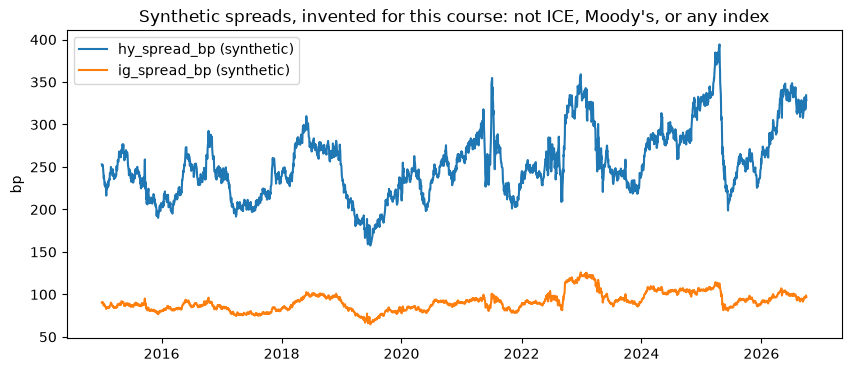

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dataset.index, dataset["hy_spread_bp"], label="hy_spread_bp (synthetic)")
ax.plot(dataset.index, dataset["ig_spread_bp"], label="ig_spread_bp (synthetic)")
ax.set_title("Synthetic spreads, invented for this course: not ICE, Moody's, or any index")
ax.set_ylabel("bp")
ax.legend()
plt.show()

**Observations**

* The dataset has 2,940 market days from 2015-01-02 to 2026-10-02, 190 of them in 2026. No date repeats, none falls on a weekend, and the 126 weekdays with no row are the same 126 the curve file has.
* Three tenors of the full curve start late (2 Mo from 2018-10-16, 4 Mo from 2022-10-19, 1.5 Month from 2025-02-18); the dataset's five tenors have a value on every row.
* The synthetic investment grade spread runs from 64.7 bp (2019-06-26) to 125.9 bp (2022-12-28); the synthetic high yield spread from 157.5 bp (2019-06-26) to 394.3 bp (2025-04-21). The high yield spread is above the investment grade spread on every row (exercise 2 checks it).
* Neither synthetic spread has a stale run of 5 or more. The yields have repeats, reported and kept.

These describe the files. The spreads are invented, so they say nothing about any real market, and none of these lines says where any yield or spread is going.

## 5.8 Live: The Same Curve from FRED, Cached

*This product uses the FRED&reg; API but is not endorsed or certified by the Federal Reserve Bank of St. Louis.*

With a key, the curve can come from FRED instead of the file. The live cell pulls all 11 series in `FRED_TREASURY` with `cached_fred_series` into `cache/`, checks each against the snapshot on every date both have, then runs the loop again to show the second pass reads today's files.

Q. Run the key cell.

In [29]:
try:
    fred_key = md.get_secret("FRED_API_KEY", env_file=ENV_FILE)
    print("FRED key: found. It is held in memory and is never printed.")
except RuntimeError as error:
    fred_key = None
    print(f"FRED key: not found. Live cells will be skipped. {error}")

FRED key: not found. Live cells will be skipped. Secret FRED_API_KEY not found. Looked in: the environment variable FRED_API_KEY, Colab's Secrets panel, and the file .env given as env_file.


Q. Pull the eleven Treasury series through the cache and check each one against the snapshot.

In [30]:
# a live cell: it needs your key and the network
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    live_cache = work / "cache"
    for live_id, live_tenor in md.FRED_TREASURY.items():
        # today's file if there is one, otherwise one request, then cached
        live_series = md.cached_fred_series(live_id, fred_key, live_cache, start="2015-01-01").dropna()
        # the check: on every date both have, FRED's value equals the snapshot's, in percent
        live_common = live_series.index.intersection(curve.index)
        live_gap = (live_series[live_common] - curve.loc[live_common, live_tenor]).abs().max()
        assert len(live_common) > 0 and live_gap <= 1e-9, f"{live_id} differs from the snapshot"
        print(f"{live_id:7} {live_tenor:6} {len(live_common):,} dates in both, largest gap {live_gap:.1e} percent")

    # the second pass: every file was written today, so no request is sent and the values are the same
    for live_id in md.FRED_TREASURY:
        live_again = md.cached_fred_series(live_id, fred_key, live_cache, start="2015-01-01")
        assert live_again.equals(md.read_cache(live_id, live_cache))
    live_files = sorted(live_path.name for live_path in live_cache.glob("DGS*.csv"))
    print(f"second pass from the cache: {len(live_files)} files, {', '.join(live_files)}")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message, because the saved run had no key.
* **With your key** you will see 11 lines, one per series, each with the number of dates FRED and the snapshot share and a largest gap of `0.0e+00` percent: FRED's `DGS` series and the Treasury file hold the same published values. Then the second pass, from the 11 files in `cache/`, with no request. Run the cell again today and both passes read the cache.

## 5.9 Live: ICE and Moody's, Metadata Only

Q. Pull the two ICE BofA spreads and Moody's Baa spread into memory with `fred_series`, never the cache, and print only what describes the pull.

In [31]:
# a live cell: licensed series, metadata only
if fred_key is None:
    print(NO_KEY_MESSAGE)
else:
    for live_id in ['BAMLC0A0CM', 'BAMLH0A0HYM2', 'BAA10Y']:
        # into memory only: fred_series, never cached_fred_series, and nothing is written
        live_series = md.fred_series(live_id, fred_key)
        live_values = live_series.dropna()
        live_weekend = int((live_series.index.dayofweek >= 5).sum())
        print(f"{live_id}: percent, {len(live_series):,} rows from {live_series.index[0].date()} to "
              f"{live_series.index[-1].date()}, {int(live_series.isna().sum())} '.' rows, {live_weekend} weekend rows")
        # checks: dates unique and ascending, and every value between 0 and 30, so in percent, never in bp
        assert live_series.index.is_unique and live_series.index.is_monotonic_increasing
        assert live_values.between(0, 30).all(), f"{live_id}: a value outside 0 to 30 percent"
        if live_id.startswith("BAML"):
            # ICE's series hold about three years
            assert live_series.index[0] >= pd.Timestamp.today() - pd.DateOffset(years=3, months=1), "more than three years"
        if SHOW_LICENSED_VALUES:
            # your screen only: converted to bp, never saved, shared, or recorded
            print((live_values * 100).tail(5).round(1).to_string())
            live_values.mul(100).plot(title=f"{live_id} in bp (licensed: your screen only)", figsize=(10, 3))
            plt.show()

    # nothing licensed reached the cache
    assert not [live_path.name for live_path in (work / "cache").iterdir() if live_path.name.startswith(md.LICENSED_PREFIXES)]
    print("cache: no licensed series written")

Live cell skipped: no FRED key was found. Every other cell runs without one.


* The saved output is the skip message.
* **With your key** you will see one line per series: units, the number of rows, the first and last date, the count of `.` rows, and the count of weekend rows. For the two ICE series, about three years of daily rows ending a day or two before the day you run it, and a few weekend rows at month ends. For `BAA10Y`, a much longer history. Then `cache: no licensed series written`.
* No value is printed unless you set `SHOW_LICENSED_VALUES` to `True` on your own machine. Then you see the last five values in bp and a chart. Keep that output to yourself.

## Excel Side by Side

Excel's Power Query does today's two joins of files without a line of code, and worksheet formulas run the same checks. Every line below was tested in Excel (16.0 build 20430, 2026-10-04).

| Job | Python | Excel (tested) | Excel returns |
| --- | --- | --- | --- |
| Stack two files of the same columns | `pd.concat([first, second])` | Power Query Append: `Table.Combine({First, Second})` on the Treasury file split at 2026 into two CSV files (2,750 and 190 rows) | 2,940 rows, 15 columns, equal to the file |
| Join the spreads to the curve on date | `md.align({...}, how="inner")` | Power Query Merge: `Table.NestedJoin(Curve, {"date"}, Spreads, {"date"}, "s", JoinKind.LeftOuter)`, then `Table.ExpandTableColumn` | 2,940 rows, 17 columns; the spread columns arrive as text (`98.8`, `334.7` on 2026-09-30) |
| Make the spreads numbers | `float_precision="round_trip"` when reading | `Table.TransformColumnTypes(Expanded, {{"ig_spread_bp", type number}, {"hy_spread_bp", type number}}, "en-US")` | numbers on all 2,940 rows, equal to the file |
| A spread beside each curve date | `md.align` | `=XLOOKUP($A2,Spreads!$A$2:$A$2941,Spreads!$B$2:$B$2941)`, filled down | equal to the file on all 2,940 rows, 0 `#N/A` |
| No weekend dates | `(dataset.index.dayofweek >= 5).sum()` | `=SUMPRODUCT(--(WEEKDAY(A2:A2941,2)>5))` | 0 |
| No repeated dates | `dataset.index.is_unique` | `=ROWS(A2:A2941)-ROWS(UNIQUE(A2:A2941))` | 0 |
| Dates in order | `dataset.index.is_monotonic_increasing` | `=SUMPRODUCT(--(A3:A2941<=A2:A2940))` | 0 |
| A spread on every date | `dataset.notna().all()` | `=COUNTBLANK(P2:P2941)` on the looked-up spreads | 0 |
| Blank cells of a late tenor | `curve["4 Mo"].isna().sum()` | `=COUNTBLANK(F2:F2941)` (column F is the 4 Mo) | 1,951 |
| First date a late tenor has a value | `curve["4 Mo"].first_valid_index()` | `=XLOOKUP(TRUE,F2:F2941<>"",A2:A2941)` | 2022-10-19 |

**Append.** In Excel: Data, Get Data, From File, From Text/CSV for each file, then Data, Get Data, Combine Queries, Append. Power Query writes `Table.Combine`, which stacks tables with the same columns, exactly as `pd.concat` does.

**Merge.** The same menu, Combine Queries, Merge: choose the curve, then the spreads, click `date` in both, and pick a left outer join. Power Query nests the matching spread rows in one column, and expanding it brings out `ig_spread_bp` and `hy_spread_bp`. A CSV file read this way gives every column as text until a type is set, which is the change-type step in the table. In Python, `read_csv` sets the types as it reads.

**XLOOKUP beside the curve.** Put the curve on one sheet and the spreads on another, both with real Excel dates in column A. Next to the curve's first date, `XLOOKUP` finds that date in the spreads' dates and returns the spread on the same row; the `$` signs fix the lookup ranges, so the formula fills down the whole column. The dates are equal in both files, so no row comes back `#N/A`.

**The checks.** `WEEKDAY(date,2)` numbers Monday 1 to Sunday 7, so `>5` marks a weekend and `SUMPRODUCT(--(...))` counts the `TRUE`s. `UNIQUE` lists each date once, so a repeated date makes the two row counts differ. Comparing each date with the one above counts any out of order. Each returned 0 on the file.

Q. Do Python's append and join give the same table as the file and as Power Query?

In [32]:
# the Treasury file split at 2026 into two parts, then stacked again: Power Query's Append
first = curve.loc[:"2025-12-31"]
second = curve.loc["2026-01-01":]
stacked = pd.concat([first, second])
print(f"append: {len(first):,} + {len(second)} = {len(stacked):,} rows, equal to the file: {stacked.equals(curve)}")

# the whole curve with the spreads joined on date: Power Query's Merge
merged = curve.join(spreads, how="left")
print(f"merge: {merged.shape[0]:,} rows, {merged.shape[1] + 1} columns with the date; 2026-09-30 spreads "
      f"{merged.loc['2026-09-30', 'ig_spread_bp']} and {merged.loc['2026-09-30', 'hy_spread_bp']} bp (synthetic)")

append: 2,750 + 190 = 2,940 rows, equal to the file: True
merge: 2,940 rows, 17 columns with the date; 2026-09-30 spreads 98.8 and 334.7 bp (synthetic)


* The same counts as Excel: 2,940 rows appended, 2,940 rows and 17 columns merged, and the same 2026-09-30 spreads, as numbers.

## Save the Day with Git

Week 1 is done, so today's Git step marks it: a **tag**, a name fixed to one commit, so `week1` always finds the code as it stood tonight, however many commits follow.

A tag needs a history to sit in. Your own `my_bondmath` folder has one, a commit a day since day 1. This work folder is new today, so the next cells rebuild week 1's history from today's files first.

Q. Make the work folder a repository.

In [33]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [34]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course3_05_dl6ckkll and nowhere else


Q. Write the `.gitignore` of day 1: `.env`, `cache/`, and the rest.

In [35]:
%%writefile .gitignore
# secrets: your .env holds real keys and is never committed
.env
# downloaded data and databases: rebuilt, never part of the record
cache/
*.db
# folders Python and pytest make
__pycache__/
.pytest_cache/

Writing .gitignore


Each day's code was added at the end of the two files, so every earlier day's file is the front part of today's: the file at the end of day 3 is everything above day 4's first line. The next cell holds the first line each day added, cuts the files back day by day, and commits each day's version.

Q. Rebuild the history: one commit for each of days 1 to 4.

In [36]:
def front_part(text, first_line_of_later_code):
    """The part of a file above a later day's first line: the file as it stood before that day."""
    cut = text.index("\n" + first_line_of_later_code)
    return text[:cut].rstrip("\n") + "\n"


# the first line each day added to each file, from day 2 on
module_starts = {
    2: 'import pandas as pd  # dated series, from day 2',
    3: 'def _check_index(',
    4: 'def _check_series(',
    5: "from datetime import date, datetime  # the cache file's date, from day 5",
}
test_starts = {
    2: 'import json  # the FRED-format samples, from day 2',
    3: 'def test_missing_weekdays_hand_index(',
    4: 'def read_treasury(',
    5: 'def test_cache_round_trip_exact(',
}
titles = {
    1: 'APIs, Keys, and Secrets',
    2: 'JSON and the FRED API',
    3: 'Market Calendars and Cleaning',
    4: 'Resampling and the As-Of Value',
}

# today's files hold every day so far
module_now = Path("marketdata.py").read_text(encoding="utf-8")
tests_now = Path("test_marketdata.py").read_text(encoding="utf-8")

for day in range(1, 5):
    # the files as they stood at the end of this day: everything above the next day's first line
    Path("marketdata.py").write_text(front_part(module_now, module_starts[day + 1]), encoding="utf-8", newline="\n")
    Path("test_marketdata.py").write_text(front_part(tests_now, test_starts[day + 1]), encoding="utf-8", newline="\n")
    message = f"Day {day}: {titles[day]}"
    !git -C "{work}" add .gitignore marketdata.py test_marketdata.py
    !git -C "{work}" commit -q -m "{message}"

# today's files back, exactly as they were
Path("marketdata.py").write_text(module_now, encoding="utf-8", newline="\n")
Path("test_marketdata.py").write_text(tests_now, encoding="utf-8", newline="\n")
print(f"marketdata.py: {len(module_now.splitlines())} lines today")

marketdata.py: 336 lines today


In [37]:
# the history so far, newest first
!git -C "{work}" log --oneline

bdd5565 Day 4: Resampling and the As-Of Value
c8af8c2 Day 3: Market Calendars and Cleaning
be70b33 Day 2: JSON and the FRED API
1aa2041 Day 1: APIs, Keys, and Secrets


* Four commits, one per day; the hashes change on every run.

Q. What does Git see now, ignored files included?

In [38]:
# M is a tracked file that changed; !! is ignored
!git -C "{work}" status --short --ignored

 M marketdata.py
 M test_marketdata.py
?? bondmath.py
?? course3_fred_format_dgs10.json
?? course3_synthetic_spreads.csv
?? treasury_par_yields.csv
!! __pycache__/
!! cache/


* ` M` on the two files: today's three functions and three tests. `!! cache/`: the cache folder from sections 5.2 and 5.3, ignored, as the `.gitignore` of day 1 promised. The data files and `bondmath.py` are copies made by the setup cell, so they stay untracked.

Q. Which line keeps the cache out?

In [39]:
# the .gitignore line that matches a file in the cache
!git -C "{work}" check-ignore -v cache/treasury_10yr.csv

.gitignore:4:cache/	cache/treasury_10yr.csv


Q. Commit today's work, tag it `week1`, and show the history with its labels.

In [40]:
# commit, then tag the commit just made; --decorate shows branch and tag names beside the commits
!git -C "{work}" add marketdata.py test_marketdata.py
!git -C "{work}" commit -q -m "Add write_cache, read_cache, and cached_fred_series, which never caches a licensed series" -m "The last functions of week 1: one request per series per day, and licensed data stays in memory."
!git -C "{work}" tag week1
!git -C "{work}" log --oneline --decorate

dd8bce8 (HEAD -> main, tag: week1) Add write_cache, read_cache, and cached_fred_series, which never caches a licensed series
bdd5565 Day 4: Resampling and the As-Of Value
c8af8c2 Day 3: Market Calendars and Cleaning
be70b33 Day 2: JSON and the FRED API
1aa2041 Day 1: APIs, Keys, and Secrets


* `(HEAD -> main, tag: week1)` beside today's commit: the branch `main` points here, and so does the tag. Tomorrow's commits move `main` forward; `week1` stays on this commit.
* `git show week1:marketdata.py` or `git diff week1` will find this exact code at any time later. A tag made this way is a plain name for a commit: nothing else is stored.

## Bring It Home

Add today's code to your own `my_bondmath` folder, commit it, and tag the end of week 1. Open a PowerShell terminal in VS Code, with the course's `.venv` active.

**Step 1.** Go to your folder and open the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code marketdata.py
code test_marketdata.py
```

Paste the code of the three `%%writefile -a marketdata.py` cells (sections 5.1, 5.2, and 5.3), without their first lines, at the end of `marketdata.py`, and the code of the two `%%writefile -a test_marketdata.py` cells at the end of `test_marketdata.py`. Save both.

**Step 2.** Run the tests.

```powershell
python -m pytest -q test_marketdata.py
```

```
....................                                                     [100%]
20 passed in 0.50s
```

**Step 3.** Check that the cache stays out of Git. The first command prints the `.gitignore` line that matches; if it prints nothing, add `cache/` to `.gitignore` before anything else.

```powershell
git check-ignore -v cache/DGS10.csv
git status --short --ignored
```

**Step 4.** Read the change, commit, and tag the week.

```powershell
git diff --stat
git add marketdata.py test_marketdata.py
git commit -m "Add write_cache, read_cache, and cached_fred_series, which never caches a licensed series" -m "The last functions of week 1: one request per series per day, and licensed data stays in memory."
git tag week1
git log --oneline --decorate -3
```

**Step 5.** With your key in `.env`, run section 5.8's loop in a notebook or script of your own with `cache_dir` set to `Path.home() / "projects" / "my_bondmath" / "cache"`. The first run of the day downloads; the second is instant.

**In Colab**, the work folder and its cache last only as long as the runtime. Download `marketdata.py` and `test_marketdata.py` from the work folder under `/tmp`.

## You Can Now

* Say why a cache helps: FRED's 120 requests a minute, speed, and working offline.
* Write a series to a cache file and read it back exactly, and say why `float_precision="round_trip"` matters.
* Use `cached_fred_series`, which downloads at most once a day and refuses a licensed series before sending anything.
* Say what ICE's and Moody's notes on FRED allow, and keep their values off every saved or shared screen.
* Build the course's daily market dataset and prove it clean with every check of week 1.
* Tag the end of a week in Git and find the tag in `git log --decorate`.

That is week 1: the data is in, checked, and dated by the market's own calendar. Week 2 measures it. Tomorrow, day 6, opens with changes: why yields and spreads change in basis points, prices in percent, and how a change over a calendar period uses the as-of value of day 4.

## Exercises

Every exercise uses the Treasury file and the synthetic spreads; none needs a key. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads both files, builds the dataset as section 5.7 did, and defines `check`, a small function that marks your answers.

In [41]:
# float_precision="round_trip" reads every number exactly as written in the file
curve = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")
spreads = pd.read_csv("course3_synthetic_spreads.csv", parse_dates=["date"], index_col="date", float_precision="round_trip")

# the course's daily market dataset: five tenors of the curve (percent) and the two synthetic spreads (bp)
TENORS = ['3 Mo', '2 Yr', '5 Yr', '10 Yr', '30 Yr']
SPREADS = ['ig_spread_bp', 'hy_spread_bp']
dataset = md.align({tenor: curve[tenor] for tenor in TENORS} | {name: spreads[name] for name in SPREADS}, how="inner")


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Add the 7 Yr and 20 Yr. Build `ex1_dataset` with `md.align` from the seven tenors `TENORS + ["7 Yr", "20 Yr"]` and the two spreads, inner join. Assert it has no missing value and as many rows as `curve`. Store its shape in **ex1_shape** and its 7 Yr on 2026-09-30, in percent, in **ex1_seven**.

In [42]:
ex1_shape = ...
ex1_seven = ...

In [43]:
check("Exercise 1 the shape", ex1_shape, (2940, 9))
check("Exercise 1 the 7 Yr on 2026-09-30", ex1_seven, 5.19)

Exercise 1 the shape: not attempted yet
Exercise 1 the 7 Yr on 2026-09-30: not attempted yet


### Exercise 2

Q. Check that the synthetic high yield spread is above the synthetic investment grade spread on every row. Store the answer, `True` or `False`, in **ex2_all_above**, and the narrowest gap, high yield less investment grade in bp, in **ex2_narrowest**. Print the date of the narrowest gap too.

In [44]:
ex2_all_above = ...
ex2_narrowest = ...

In [45]:
check("Exercise 2 above on every row", ex2_all_above, True)
check("Exercise 2 the narrowest gap", ex2_narrowest, 91.5)

Exercise 2 above on every row: not attempted yet
Exercise 2 the narrowest gap: not attempted yet


### Exercise 3

Q. Add a function to your module. `dataset_checks(frame)` stops at the first failed check of a daily dataset and returns `None` when all pass. Write the docstring first. The checks, in order: unique ascending dates (use the module's `_check_index`), no Saturday or Sunday, no missing value in any column, and no run of 5 or more identical values in a column whose name ends in `_bp` (use `stale_runs`). Each failure raises `ValueError` with a message that names the check: the words `weekend`, `missing`, and `stale`. Then add `test_dataset_checks_stop_on_first_failure`: a three-row frame that passes, then one with a weekend date, one with a missing value, and one with five identical spreads, each raising.

Run pytest and reload the module. Store whether `md.dataset_checks(dataset)` returns `None` in **ex3_passes**. Then move every date of the dataset back one day, `dataset.set_axis(dataset.index - pd.Timedelta(days=1))`, and store whether `dataset_checks` raises a `ValueError` with `weekend` in its message in **ex3_caught**.

Write the function in the cell that starts with `%%writefile -a marketdata.py` and the test in the one that starts with `%%writefile -a test_marketdata.py`, and run each of those cells once.

In [46]:
%%writefile -a marketdata.py


# Exercise 3: write dataset_checks(frame) below this line

Appending to marketdata.py


In [47]:
%%writefile -a test_marketdata.py


# Exercise 3: write test_dataset_checks_stop_on_first_failure() below this line

Appending to test_marketdata.py


In [48]:
# run pytest, reload the module, then store the two answers
ex3_passes = ...
ex3_caught = ...

In [49]:
check("Exercise 3 the dataset passes", ex3_passes, True)
check("Exercise 3 the shifted dataset is caught", ex3_caught, True)

Exercise 3 the dataset passes: not attempted yet
Exercise 3 the shifted dataset is caught: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that builds the market dataset from the two files, and you give it the docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Build the daily market dataset from the Treasury file and the synthetic spreads.

    Units: yields in percent and spreads in bp, as the files hold them. Convention: one row per date of the
    Treasury file, each the US business date the values are published for, with the spreads of that same
    date beside the curve. Dates are calendar dates with no time and no time zone: nothing is localized or
    converted.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, and it contains one bug.

In [50]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
def build_market_dataset(curve_path, spreads_path, tenors):
    """Build the daily market dataset from the Treasury file and the synthetic spreads.

    Units: yields in percent and spreads in bp, as the files hold them. Convention: one row per date of the
    Treasury file, each the US business date the values are published for, with the spreads of that same
    date beside the curve. Dates are calendar dates with no time and no time zone: nothing is localized or
    converted.
    """
    curve = pd.read_csv(curve_path, parse_dates=["date"], index_col="date", float_precision="round_trip")[tenors]
    spreads = pd.read_csv(spreads_path, parse_dates=["date"], index_col="date", float_precision="round_trip")
    # put every date on New York time to be safe, then keep the calendar date
    for frame in (curve, spreads):
        frame.index = frame.index.tz_localize("UTC").tz_convert("America/New_York").normalize().tz_localize(None)
    # the spreads beside the curve, on the dates both files have
    return curve.join(spreads, how="inner")

Q. Before you run the next cell: the Treasury file starts on Friday 2015-01-02. What will the dataset's first three dates be? Read the loop in the middle of the function.

In [51]:
print(build_market_dataset("treasury_par_yields.csv", "course3_synthetic_spreads.csv", TENORS).index[:3])

DatetimeIndex(['2015-01-01', '2015-01-04', '2015-01-05'], dtype='datetime64[us]', name='date', freq=None)


Q. Test the function against its docstring before you trust it.

In [52]:
# the test, written from the docstring before the code is trusted
dataset_ai = build_market_dataset("treasury_par_yields.csv", "course3_synthetic_spreads.csv", TENORS)
file_dates = pd.read_csv("treasury_par_yields.csv", parse_dates=["date"])["date"]
assert dataset_ai.loc["2026-09-30", "10 Yr"] == 5.29, "the row for 2026-09-30 does not hold that day's 10 Yr"
assert dataset_ai.loc["2026-09-30", "ig_spread_bp"] == 98.8, "the row for 2026-09-30 does not hold that day's spread"
assert dataset_ai.index.equals(pd.DatetimeIndex(file_dates, name="date")), "the dates are not the file's dates"
print("Every date is the file's date, and 2026-09-30 holds 5.29 percent and 98.8 bp")

AssertionError: the row for 2026-09-30 does not hold that day's 10 Yr

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed dataset's 10 Yr on 2026-09-30 in **ex4_ten**, its `ig_spread_bp` on that date in **ex4_ig**, and whether its dates equal `curve.index`, `dataset_ai.index.equals(curve.index)`, in **ex4_same_dates**.

In [53]:
# fix the function above and run the test again, then store the three answers
ex4_ten = ...
ex4_ig = ...
ex4_same_dates = ...

In [54]:
check("Exercise 4 the 10 Yr on 2026-09-30", ex4_ten, 5.29)
check("Exercise 4 the spread on 2026-09-30", ex4_ig, 98.8)
check("Exercise 4 the same dates", ex4_same_dates, True)

Exercise 4 the 10 Yr on 2026-09-30: not attempted yet
Exercise 4 the spread on 2026-09-30: not attempted yet
Exercise 4 the same dates: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```